**Machine Learning-Based Prediction of Cereal and Legume Crop Yield in Northern Kazakhstan Using Climatic and Remote Sensing Data**
---------

**Loading libraries and Datasets**

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from io import StringIO
import ee
import geemap
import ipyleaflet
import ipywidgets
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import scipy.stats as stats

In [2]:
ee.Authenticate(force=True, auth_mode='localhost')
ee.Initialize(project='ee-kz-499211')


Successfully saved authorization token.


In [3]:
akmola = pd.read_csv('akmola.csv')
akmola.head()

,Unnamed: 0,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Всего по области,7.1,8.5,9.6,11.6,7.5,11.2,5.2,15.6,7.0,...,11.6,11.2,11.7,9.5,11.6,8.7,11.6,6.9,13.1,15.5
1,г.а. Кокшетау,2.1,4.7,7.3,9.7,3.0,6.3,3.1,16.7,5.5,...,15.6,19.4,15.0,11.7,15.8,10.0,14.5,10.2,17.9,12.9
2,г.а Косшы,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,7.6,5.7,16.4,6.9
3,г.а. Степногорск,3.0,2.3,5.8,9.3,-,6.8,0.6,5.0,4.0,...,5.2,4.9,10.4,8.0,9.5,9.8,8.7,2.9,14.9,18.4
4,Аккольский,4.7,7.1,9.4,9.2,4.0,12.7,5.6,12.8,5.9,...,10.9,9.4,10.5,9.6,12.0,8.9,10.6,5.1,14.5,15.6


In [4]:
kostanay = pd.read_csv('kostanay.csv')
kostanay.head()

,Unnamed: 0,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Костанайская область,15.0,3.7,14.6,6.3,9.8,4.2,7.0,9.9,4.0,...,9.9,11.4,10.8,11.6,11.6,7.4,10.1,7.1,13.6,10.7
1,г.Костанай,-,-,-,-,-,-,-,10.1,2.7,...,13.5,12.9,13.3,13.9,14.8,7.2,10.9,7.0,11.7,13.3
2,Аркалык г.а.,7.0,5.1,-,-,-,-,-,3.5,3.3,...,7.4,6.4,7.1,5.3,7.4,7.1,9.6,4.0,8.5,4.1
3,Лисаковск г.а.,16.5,2.4,13.1,4.0,13.3,2.4,4.0,5.9,0.3,...,5.6,5.8,6.3,6.6,6.8,4.0,3.0,5.2,8.4,6.9
4,Рудный г.а.,-,-,-,-,-,-,-,-,-,...,5.4,5.0,-,13.3,-,5.0,3.4,-,8.2,-


In [5]:
northkaz = pd.read_csv('north-kaz.csv')
northkaz.head()

,Unnamed: 0,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Итого по области,14.7,6.4,17.8,11.3,10.9,7.7,10.5,11.7,7.0,...,15.7,16.3,15.5,14.4,14.3,11.5,14.7,11.2,18.4,19.7
1,Петропавловск,6.8,1.0,12.9,20.0,10.3,7.1,15.1,17.4,5.2,...,-,4.5,3.5,1.9,-,-,-,30.0,21.9,10.0
2,Айыртауский,17.7,6.8,19.0,9.5,12.1,7.7,10.1,11.4,6.6,...,14.6,16.0,13.8,13.1,14.0,10.4,16.4,12.2,17.6,20.9
3,Акжарский,10.2,3.5,8.3,13.7,9.5,6.7,10.7,8.2,6.9,...,14.5,12.8,14.1,12.6,13.0,11.8,9.9,5.9,15.7,14.5
4,М.Жумабаева,14.9,8.2,21.4,15.0,12.0,12.3,12.1,12.9,9.8,...,18.1,19.5,16.2,14.2,14.2,13.1,11.1,12.7,19.0,22.6


In [6]:
regions = ee.FeatureCollection("FAO/GAUL/2015/level2")
kz_regions = regions.filter(ee.Filter.eq('ADM0_NAME', 'Kazakhstan'))
north_regions = kz_regions.filter(ee.Filter.inList('ADM1_NAME',['Severo-kazachstanskaya','Kustanayskaya','Akmolinskaya']))
def add_coords(feature):
    centroid = feature.geometry().centroid()
    coords = centroid.coordinates()
    return feature.set({
        'Longitude': coords.get(0),
        'Latitude': coords.get(1)})
north_regions_coords = north_regions.map(add_coords)

In [7]:
coords_df = geemap.ee_to_df(north_regions_coords.select(['ADM1_NAME','ADM2_NAME', 'Latitude', 'Longitude']))
coords_df = coords_df.rename(columns={'ADM2_NAME':'District'})
coords_df

,ADM1_NAME,District,Latitude,Longitude
0,Akmolinskaya,Akkol,52.158840,71.546248
1,Akmolinskaya,Arshaly,50.946737,72.235343
2,Akmolinskaya,Astrakhanskiy,51.502883,69.737072
3,Akmolinskaya,Atbasar,51.470130,68.473124
4,Akmolinskaya,Bulandy,52.258009,70.069939
5,Akmolinskaya,Egindykol,50.983209,69.315993
6,Akmolinskaya,Ereymentau,51.857507,73.138526
7,Akmolinskaya,Esil,51.879700,66.283677
8,Akmolinskaya,Korghalzhyn,50.531974,69.925013
9,Akmolinskaya,Sandyktau,52.388053,68.696861


In [8]:
coords_df.loc[(coords_df['District'] == 'Esil') & (coords_df['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
coords_df.loc[(coords_df['District'] == 'Esil') &(coords_df['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'

In [9]:
coords_df = coords_df.rename(columns={'ADM2_NAME': 'District'})
coords_df = coords_df.drop(columns=['ADM1_NAME'])
coords_df

,District,Latitude,Longitude
0,Akkol,52.158840,71.546248
1,Arshaly,50.946737,72.235343
2,Astrakhanskiy,51.502883,69.737072
3,Atbasar,51.470130,68.473124
4,Bulandy,52.258009,70.069939
5,Egindykol,50.983209,69.315993
6,Ereymentau,51.857507,73.138526
7,Esil_Akmola,51.879700,66.283677
8,Korghalzhyn,50.531974,69.925013
9,Sandyktau,52.388053,68.696861


In [10]:
dataset = ee.ImageCollection('MODIS/061/MOD13Q1') \
    .filterDate('2018-01-01', '2018-05-01')

ndvi = dataset.select('NDVI').median().multiply(0.0001)

In [11]:
months = [5, 6, 7, 8, 9]
def calc_ndvi_year(year):
    def add_ndvi(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            ndvi = (
                ee.ImageCollection('MODIS/061/MOD13Q1')
                .filterDate(start, end)
                .select('NDVI')
                .median()
                .multiply(0.0001)
            )
            value = ndvi.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=250,
                maxPixels=1e13
            ).get('NDVI')
            result = result.set(f'NDVI_{m}', value)
        return result.set('year', year)
    return north_regions.map(add_ndvi)

In [12]:
final_ndvi = calc_ndvi_year(2000)
for y in range(2001, 2026):
    final_ndvi = final_ndvi.merge(calc_ndvi_year(y))

In [13]:
#task = ee.batch.Export.table.toDrive(collection=final_ndvi,description='NDVI_by_regions',fileFormat='CSV')
#task.start()

In [14]:
ndvi_d = pd.read_csv('NDVI_by_regions.csv')
ndvi_d

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,3000,0.476270,0.601548,0.523072,0.383295,0.288038,Member State,1000,1.394564,7.625067,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,3000,0.426410,0.568163,0.528157,0.360567,0.265945,Member State,1000,0.774513,5.739223,2000,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,3000,0.420540,0.542232,0.468522,0.306808,0.248698,Member State,1000,0.942570,5.930184,2000,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,3000,0.421842,0.467529,0.406347,0.266730,0.230477,Member State,1000,1.398906,7.168289,2000,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,3000,0.430329,0.642227,0.622543,0.380838,0.282489,Member State,1000,0.691933,6.174336,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1529,2_0002000000000000019f,132,Kazakhstan,1726,Severo-kazachstanskaya,37287,Timiryazev,NO,3000,0.451923,0.635450,0.686953,0.518982,0.372010,Member State,1000,0.651360,4.548179,2025,"{""type"":""Polygon"",""coordinates"":[[[66.22805814..."
1530,2_000200000000000001a0,132,Kazakhstan,1726,Severo-kazachstanskaya,37288,Tselinniy,NO,3000,0.429031,0.625591,0.625412,0.475018,0.343711,Member State,1000,1.608963,8.312733,2025,"{""type"":""Polygon"",""coordinates"":[[[67.12354379..."
1531,2_000200000000000001a1,132,Kazakhstan,1726,Severo-kazachstanskaya,37289,Ualikhanov,NO,3000,0.479427,0.467569,0.475622,0.471686,0.381981,Member State,1000,1.739326,11.008570,2025,"{""type"":""Polygon"",""coordinates"":[[[73.95217984..."
1532,2_000200000000000001a2,132,Kazakhstan,1726,Severo-kazachstanskaya,37290,Zerendy,NO,3000,0.508368,0.613479,0.611409,0.533867,0.453824,Member State,1000,1.125464,7.375035,2025,"{""type"":""Polygon"",""coordinates"":[[[69.36579827..."


In [15]:
months = [5, 6, 7, 8, 9]
def calc_evi_year(year):
    def add_evi(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            evi = (
                ee.ImageCollection('MODIS/061/MOD13Q1')
                .filterDate(start, end)
                .select('EVI')
                .median()
                .multiply(0.0001)
            )
            value = evi.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=250,
                maxPixels=1e13
            ).get('EVI')
            result = result.set(f'EVI_{m}', value)
        return result.set('Year', year)
    return north_regions.map(add_evi)
final_evi = calc_evi_year(2002)
for y in range(2003, 2024):
    final_evi = final_evi.merge(calc_evi_year(y))

In [16]:
#task = ee.batch.Export.table.toDrive(collection=final_evi,description='EVI_by_regions',fileFormat='CSV')
#task.start()

In [17]:
evi = pd.read_csv('EVI_by_regions.csv')
evi.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EVI_5,EVI_6,EVI_7,EVI_8,EVI_9,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0002...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,0.260005,0.326458,0.325473,0.214567,0.137916,3000,Member State,1000,1.394564,7.625067,2002,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0002...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,0.212535,0.340554,0.356106,0.241694,0.142882,3000,Member State,1000,0.774513,5.739223,2002,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0002...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,0.220175,0.342061,0.361960,0.209930,0.137384,3000,Member State,1000,0.942570,5.930184,2002,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0002...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,0.234145,0.307386,0.299985,0.178065,0.117718,3000,Member State,1000,1.398906,7.168289,2002,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0002...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,0.230475,0.384798,0.410421,0.237748,0.142240,3000,Member State,1000,0.691933,6.174336,2002,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."


In [18]:
years = list(range(2000, 2026))
months = [5, 6, 7, 8, 9]
def calc_temp_year(year):
    def add_temp(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('temperature_2m')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('temperature_2m')

            result = result.set(
                f'Temp_{m}',
                value
            )
        return result.set('year', year)
    return north_regions.map(add_temp)

In [19]:
final_temp = calc_temp_year(2000)

for y in range(2001, 2026):
    final_temp = final_temp.merge(calc_temp_year(y))

In [20]:
task = ee.batch.Export.table.toDrive(collection=final_temp,description='north_kaz_weather',fileFormat='CSV')
task.start()

In [21]:
weather = pd.read_csv('north_kaz_weather.csv')
weather.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Temp_5,Temp_6,Temp_7,Temp_8,Temp_9,year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,3000,Member State,1000,1.394564,7.625067,283.842540,291.738791,292.923075,291.700046,284.391856,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,3000,Member State,1000,0.774513,5.739223,284.239571,291.416077,293.003605,292.382622,284.678874,2000,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,3000,Member State,1000,0.942570,5.930184,284.408079,292.679117,293.770673,293.118075,285.194313,2000,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,3000,Member State,1000,1.398906,7.168289,284.246318,293.264829,294.407422,293.259846,285.240255,2000,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,3000,Member State,1000,0.691933,6.174336,283.364718,291.465926,292.237010,291.202061,284.102214,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."


In [22]:
years = list(range(2000, 2026))
months = [5, 6, 7, 8, 9]
def calc_prec_year(year):
    def add_prec(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('total_precipitation_sum')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('total_precipitation_sum')
            result = result.set(
                f'Precip_{m}',
                value
            )
        return result.set('year', year)
    return north_regions.map(add_prec)
    
final_prec = calc_prec_year(2000)
for y in range(2001, 2026):
    final_prec = final_prec.merge(calc_prec_year(y))

In [23]:
#task = ee.batch.Export.table.toDrive(collection=final_prec,description='Precipitation_northkz',fileFormat='CSV')
#task.start()

In [24]:
prec=pd.read_csv('Precipitation_northkz.csv')
prec.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,Precip_5,Precip_6,Precip_7,Precip_8,Precip_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,3000,0.082929,0.098439,0.037709,0.044035,0.046814,Member State,1000,1.394564,7.625067,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,3000,0.118791,0.086826,0.027220,0.043736,0.042440,Member State,1000,0.774513,5.739223,2000,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,3000,0.061404,0.085150,0.028321,0.025786,0.039048,Member State,1000,0.942570,5.930184,2000,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,3000,0.061139,0.053357,0.024232,0.026660,0.031625,Member State,1000,1.398906,7.168289,2000,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,3000,0.073268,0.115209,0.039816,0.044963,0.036087,Member State,1000,0.691933,6.174336,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."


In [25]:
years = list(range(2000, 2026))
months = [5, 6, 7, 8, 9]
def calc_soil_year(year):
    def add_soil(feature):
        result = feature.set('Year', year)
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .first())
            soil = (
                img.select('volumetric_soil_water_layer_1').multiply(7)
                .add(img.select('volumetric_soil_water_layer_2').multiply(21))
                .add(img.select('volumetric_soil_water_layer_3').multiply(72))
                .divide(100)
                .rename(f'Soil_{m}'))

            value = soil.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=1000,
                maxPixels=1e13
            ).get(f'Soil_{m}')
            result = result.set(f'Soil_{m}', value)
        return result
    return north_regions.map(add_soil)
    
final_soil = calc_soil_year(2000)
for y in range(2001, 2026):
    final_soil = final_soil.merge(calc_soil_year(y))

In [26]:
#task = ee.batch.Export.table.toDrive(collection=final_soil,description='Soil_northkz',fileFormat='CSV')
#task.start()

In [27]:
soil = pd.read_csv('Soil_northkz.csv')
soil.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Soil_5,Soil_6,Soil_7,Soil_8,Soil_9,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,3000,Member State,1000,1.394564,7.625067,0.319789,0.334453,0.293206,0.269319,0.261753,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,3000,Member State,1000,0.774513,5.739223,0.288869,0.297093,0.240309,0.205699,0.196020,2000,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,3000,Member State,1000,0.942570,5.930184,0.333311,0.325663,0.291810,0.261209,0.254992,2000,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,3000,Member State,1000,1.398906,7.168289,0.308192,0.288356,0.248958,0.226649,0.223626,2000,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,3000,Member State,1000,0.691933,6.174336,0.378346,0.388986,0.354945,0.322041,0.310637,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."


In [28]:
def add_ph(feature):
    ph = ee.Image("OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02")
    ph_weighted = (
        ph.select('b0').multiply(5)
        .add(ph.select('b10').multiply(10))
        .add(ph.select('b30').multiply(15))
        .divide(30)
        .divide(10)
        .rename('pH'))
    value = ph_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('pH')
    return feature.set('pH', value)
ph_fc = north_regions.map(add_ph)
ph_df = geemap.ee_to_df(ph_fc)

In [29]:
def add_soc(feature):
    soc = ee.Image("OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02")
    soc_weighted = (
        soc.select('b0').multiply(5)
        .add(soc.select('b10').multiply(10))
        .add(soc.select('b30').multiply(15))
        .divide(30)
        .rename('SOC'))
    value = soc_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('SOC')
    return feature.set('SOC', value)
soc_fc = north_regions.map(add_soc)
soc_df = geemap.ee_to_df(soc_fc)

In [30]:
def add_clay(feature):
    clay = ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
    clay_weighted = (
        clay.select('b0').multiply(5)
        .add(clay.select('b10').multiply(10))
        .add(clay.select('b30').multiply(15))
        .divide(30)
        .rename('Clay'))
    value = clay_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('Clay')
    return feature.set('Clay', value)
clay_fc = north_regions.map(add_clay)
clay_df = geemap.ee_to_df(clay_fc)

In [31]:
years = list(range(2000, 2026))
months = [5, 6, 7, 8, 9]
def calc_evap_year(year):
    def add_evap(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('evaporation_from_vegetation_transpiration_sum')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('evaporation_from_vegetation_transpiration_sum')
            result = result.set(
                f'Evap_{m}',
                value
            )
        return result.set('Year', year)
    return north_regions.map(add_evap)

final_evap = calc_evap_year(2000)
for y in range(2001, 2026):
    final_evap = final_evap.merge(calc_evap_year(y))

In [32]:
#task = ee.batch.Export.table.toDrive(collection=final_evap,description='Evap_northkz',fileFormat='CSV')
#task.start()

In [33]:
evap = pd.read_csv('Evap_northkz.csv')
evap.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,Evap_5,Evap_6,Evap_7,Evap_8,Evap_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37163,Akkol,NO,3000,-0.001879,-0.002864,-0.003289,-0.003298,-0.002399,Member State,1000,1.394564,7.625067,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37164,Arshaly,NO,3000,-0.001600,-0.003406,-0.004622,-0.004822,-0.003874,Member State,1000,0.774513,5.739223,2000,"{""type"":""Polygon"",""coordinates"":[[[71.61099131..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37165,Astrakhanskiy,NO,3000,-0.002429,-0.003461,-0.003901,-0.004008,-0.002589,Member State,1000,0.942570,5.930184,2000,"{""type"":""Polygon"",""coordinates"":[[[70.20191093..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37166,Atbasar,NO,3000,-0.000941,-0.001325,-0.001448,-0.001481,-0.000953,Member State,1000,1.398906,7.168289,2000,"{""type"":""Polygon"",""coordinates"":[[[68.97307637..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1714,Akmolinskaya,37167,Bulandy,NO,3000,-0.000556,-0.001115,-0.001638,-0.001725,-0.001545,Member State,1000,0.691933,6.174336,2000,"{""type"":""Polygon"",""coordinates"":[[[70.16545775..."


In [34]:
srtm = ee.Image('USGS/SRTMGL1_003')
def add_elevation(feature):
    elevation = srtm.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e13).get('elevation')
    return feature.set('Elevation', elevation)
elevation_fc = north_regions.map(add_elevation)
elev_df = geemap.ee_to_df(elevation_fc)

In [35]:
terrain = ee.Terrain.products(srtm)
slope = terrain.select('slope')

def add_slope(feature):
    slope_mean = slope.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e13).get('slope')
    return feature.set('Slope', slope_mean)
slope_fc = elevation_fc.map(add_slope)

In [36]:
elev_df = geemap.ee_to_df(elevation_fc)
terrain_df = geemap.ee_to_df(slope_fc)

In [37]:
northkaz = northkaz.rename(columns={'Unnamed: 0': 'District'})
northkaz = northkaz[northkaz['District'] != 'Итого по области']
northkaz = northkaz[northkaz['District'] != 'Петропавловск']
northkaz.head()

,District,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
2,Айыртауский,17.7,6.8,19.0,9.5,12.1,7.7,10.1,11.4,6.6,...,14.6,16.0,13.8,13.1,14.0,10.4,16.4,12.2,17.6,20.9
3,Акжарский,10.2,3.5,8.3,13.7,9.5,6.7,10.7,8.2,6.9,...,14.5,12.8,14.1,12.6,13.0,11.8,9.9,5.9,15.7,14.5
4,М.Жумабаева,14.9,8.2,21.4,15.0,12.0,12.3,12.1,12.9,9.8,...,18.1,19.5,16.2,14.2,14.2,13.1,11.1,12.7,19.0,22.6
5,Есильский,17.3,5.7,22.1,12.1,11.0,8.0,12.7,13.5,7.9,...,16.4,17.6,17.4,17.8,18.0,13.7,17.3,17.2,19.3,24.8
6,Жамбылский,15.5,4.5,19.5,10.1,9.0,4.5,9.2,12.0,5.6,...,18.1,18.7,19.2,15.9,14.7,10.4,18.2,12.5,18.5,19.8


In [38]:
northkaz = northkaz.replace('-', np.nan)
northkaz.isna().sum()
northkaz

,District,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
2,Айыртауский,17.7,6.8,19.0,9.5,12.1,7.7,10.1,11.4,6.6,...,14.6,16.0,13.8,13.1,14.0,10.4,16.4,12.2,17.6,20.9
3,Акжарский,10.2,3.5,8.3,13.7,9.5,6.7,10.7,8.2,6.9,...,14.5,12.8,14.1,12.6,13.0,11.8,9.9,5.9,15.7,14.5
4,М.Жумабаева,14.9,8.2,21.4,15.0,12.0,12.3,12.1,12.9,9.8,...,18.1,19.5,16.2,14.2,14.2,13.1,11.1,12.7,19.0,22.6
5,Есильский,17.3,5.7,22.1,12.1,11.0,8.0,12.7,13.5,7.9,...,16.4,17.6,17.4,17.8,18.0,13.7,17.3,17.2,19.3,24.8
6,Жамбылский,15.5,4.5,19.5,10.1,9.0,4.5,9.2,12.0,5.6,...,18.1,18.7,19.2,15.9,14.7,10.4,18.2,12.5,18.5,19.8
7,Кызылжарский,17.8,13.2,23.4,13.2,11.5,11.0,15.1,21.2,10.6,...,17.3,18.0,18.3,18.8,18.0,15.5,21.1,17.6,21.7,23.8
8,Мамлютский,16.4,10.2,23.4,13.5,12.4,11.0,12.4,20.9,7.5,...,14.9,17.5,15.4,17.8,17.3,13.8,21.2,15.9,20.1,23.4
9,Шал акына,17.8,5.0,23.3,11.0,10.0,5.5,9.8,11.1,5.9,...,14.6,16.0,14.4,13.8,15.6,11.8,17.2,10.4,18.7,19.1
10,Аккайынский,13.2,7.1,22.5,11.5,11.0,7.6,14.9,12.3,8.6,...,18.7,19.7,17.4,16.8,15.8,15.4,16.1,13.3,22.3,24.6
11,Тайыншинский,11.5,4.6,12.2,10.5,11.2,7.2,9.9,7.2,5.5,...,14.9,14.0,14.1,14.0,11.5,10.2,11.3,8.2,20.1,18.5


In [39]:
northkaz = pd.melt(northkaz, id_vars='District', var_name='Year', value_name='Yield')

In [40]:
northkaz['Year'] = pd.to_numeric(northkaz['Year'])
northkaz = northkaz[(northkaz['Year'] >= 2004)&(northkaz['Year'] <= 2023)]
northkaz

,District,Year,Yield
350,Айыртауский,2004,8.1
351,Акжарский,2004,8.9
352,М.Жумабаева,2004,9.6
353,Есильский,2004,10.7
354,Жамбылский,2004,8.1
...,...,...,...
845,NaN,2023,NaN
846,NaN,2023,NaN
847,NaN,2023,NaN
848,NaN,2023,NaN


In [41]:
northkaz = northkaz.dropna()

In [42]:
district_map = { 
    'Айыртауский': 'Ayirtau',
    'Акжарский': 'Akzhar',
    'Есильский': 'Esil_SKO',
    'Жамбылский': 'Zhambyl',
    'Кызылжарский': 'Kyzyljar',
    'Мамлютский': 'Mamlyut',
    'Шал акына': 'Sergeevskiy',
    'Аккайынский': 'Akkain',
    'Тайыншинский': 'Tayinsha',
    'Тимирязевский': 'Timiryazev',
    'Уалихановский': 'Ualikhanov',
    'М.Жумабаева': 'Bulayev',
    'Г.Мусрепова': 'Tselinniy'}
northkaz

,District,Year,Yield
350,Айыртауский,2004,8.1
351,Акжарский,2004,8.9
352,М.Жумабаева,2004,9.6
353,Есильский,2004,10.7
354,Жамбылский,2004,8.1
...,...,...,...
833,Аккайынский,2023,13.3
834,Тайыншинский,2023,8.2
835,Тимирязевский,2023,9.9
836,Уалихановский,2023,5.9


In [43]:
northkaz['District'] = northkaz['District'].map(district_map)
northkaz

/var/folders/c1/wzq4fr5d1sl83wscpxfqjj_00000gn/T/ipykernel_8346/3544825858.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  northkaz['District'] = northkaz['District'].map(district_map)


,District,Year,Yield
350,Ayirtau,2004,8.1
351,Akzhar,2004,8.9
352,Bulayev,2004,9.6
353,Esil_SKO,2004,10.7
354,Zhambyl,2004,8.1
...,...,...,...
833,Akkain,2023,13.3
834,Tayinsha,2023,8.2
835,Timiryazev,2023,9.9
836,Ualikhanov,2023,5.9


In [44]:
akmola = akmola.replace('-', np.nan)
akmola.isna().sum()

Unnamed: 0    1
2004          2
2005          2
2006          2
2007          2
2008          3
2009          2
2010          2
2011          2
2012          2
2013          2
2014          2
2015          2
2016          2
2017          2
2018          2
2019          2
2020          2
2021          2
2022          1
2023          1
2024          1
2025          1
dtype: int64

In [45]:
akmola = akmola.rename(columns={'Unnamed: 0': 'District'})
akmola = akmola[akmola['District'] != 'Всего по области']
akmola = pd.melt(akmola, id_vars='District', var_name='Year', value_name='Yield')
akmola['Year'] = pd.to_numeric(akmola['Year'])
akmola = akmola[(akmola['Year'] >= 2004)&(akmola['Year'] <= 2023)]
akmola

,District,Year,Yield
0,г.а. Кокшетау,2004,2.1
1,г.а Косшы,2004,NaN
2,г.а. Степногорск,2004,3.0
3,Аккольский,2004,4.7
4,Аршалынский,2004,7.9
...,...,...,...
415,Сандыктауский,2023,12.2
416,Целиноградский,2023,5.1
417,Шортандинский,2023,6.4
418,Бурабайский,2023,7.5


In [46]:
akmola = akmola.dropna()
akmola

,District,Year,Yield
0,г.а. Кокшетау,2004,2.1
2,г.а. Степногорск,2004,3.0
3,Аккольский,2004,4.7
4,Аршалынский,2004,7.9
5,Астраханский,2004,7.0
...,...,...,...
414,Коргалжынский,2023,4.7
415,Сандыктауский,2023,12.2
416,Целиноградский,2023,5.1
417,Шортандинский,2023,6.4


In [47]:
akmola_mapping = {
    'Аккольский ': 'Akkol',
    'Аршалынский ': 'Arshaly',
    'Астраханский ': 'Astrakhanskiy',
    'Атбасарский ': 'Atbasar',
    'Буландынский ': 'Bulandy',
    'Егиндыкольский ': 'Egindykol',
    'Ерейментауский ': 'Ereymentau',
    'Есильский ': 'Esil_Akmola',
    'Коргалжынский ': 'Korghalzhyn',
    'Сандыктауский ': 'Sandyktau',
    'Целиноградский ': 'Tselinograd',
    'Шортандинский ': 'Shortandy',
    'Жаксынский ': 'Zhaksy',
    'Жаркаинский ': 'Zharkaiyn'}

akmola['District'] = akmola['District'].replace(akmola_mapping)
akmola

/var/folders/c1/wzq4fr5d1sl83wscpxfqjj_00000gn/T/ipykernel_8346/2059912553.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  akmola['District'] = akmola['District'].replace(akmola_mapping)


,District,Year,Yield
0,г.а. Кокшетау,2004,2.1
2,г.а. Степногорск,2004,3.0
3,Akkol,2004,4.7
4,Arshaly,2004,7.9
5,Astrakhanskiy,2004,7.0
...,...,...,...
414,Korghalzhyn,2023,4.7
415,Sandyktau,2023,12.2
416,Tselinograd,2023,5.1
417,Shortandy,2023,6.4


In [48]:
kostanay = kostanay.replace('-', np.nan)
kostanay.isna().sum()

Unnamed: 0     5
1990           9
1991           7
1992          10
1993          10
1994          10
1995          10
1996          10
1997           6
1998           6
1999           5
2000           5
2001           5
2002           5
2003           5
2004           5
2005           5
2006           5
2007           6
2008           7
2009           6
2010           5
2011           5
2012           6
2013           5
2014           5
2015           5
2016           6
2017           5
2018           6
2019           5
2020           5
2021           6
2022           5
2023           6
dtype: int64

In [49]:
kostanay = kostanay.rename(columns={'Unnamed: 0': 'District'})
kostanay = kostanay[kostanay['District'] != 'Костанайская область']
kostanay = pd.melt(kostanay, id_vars='District', var_name='Year', value_name='Yield')
kostanay['Year'] = pd.to_numeric(kostanay['Year'])
kostanay = kostanay[(kostanay['Year'] >= 2004)&(kostanay['Year'] <= 2023)]
kostanay.head()

,District,Year,Yield
350,г.Костанай,2004,10.4
351,Аркалык г.а.,2004,10.6
352,Лисаковск г.а.,2004,14.0
353,Рудный г.а.,2004,5.0
354,Алтынсаринский,2004,8.0


In [50]:
kostanay.isna().sum()
kostanay = kostanay.dropna()
kostanay_mapping = {
    'Алтынсаринский': 'Altynsarin',
    'Амангельдинский': 'Amangeldi',
    'Аркалык г.а.': 'Arkalyk City area',
    'Аулиекольский': 'Auliekol',
    'Денисовский': 'Denisovskiy',
    'Федоровский': 'Fedorovskiy',
    'Камыстинский': 'Kamysty',
    'Карабалыкский': 'Karabalyk',
    'Карасуский': 'Karasu',
    'Мендыкаринский': 'Mendykara',
    'Наурзумский': 'Nauryzym',
    'Костанайский': 'Qostanay',
    'Сарыкольский': 'Sarykol',
    'Беимбета Майлина': 'Taran', 
    'Узункольский': 'Uzunkol',
    'Джангельдинский': 'Zhangyeldi',
    'Житикаринский': 'Zhitikara'}
valid = list(kostanay_mapping.keys())
kostanay = kostanay[kostanay['District'].isin(valid)]

kostanay['District'] = kostanay['District'].replace(kostanay_mapping)

In [51]:
northkaz["Region"] = "North Kazakhstan"
akmola["Region"] = "Akmola"
kostanay["Region"] = "Kostanay"
yield_df = pd.concat([northkaz, akmola, kostanay],ignore_index=True).sort_values('Year')
yield_df.head()

/var/folders/c1/wzq4fr5d1sl83wscpxfqjj_00000gn/T/ipykernel_8346/1038233432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  northkaz["Region"] = "North Kazakhstan"
/var/folders/c1/wzq4fr5d1sl83wscpxfqjj_00000gn/T/ipykernel_8346/1038233432.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  akmola["Region"] = "Akmola"


,District,Year,Yield,Region
0,Ayirtau,2004,8.1,North Kazakhstan
275,Sandyktau,2004,8.0,Akmola
274,Korghalzhyn,2004,4.6,Akmola
273,Зерендинский,2004,8.9,Akmola
272,Zharkaiyn,2004,7.4,Akmola


In [52]:
ndvi_d=ndvi_d.drop(columns=['system:index','ADM0_CODE','ADM0_NAME', 'ADM1_CODE', 'ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'])
ndvi_d = ndvi_d.rename(columns={'ADM2_NAME': 'District', 'year': 'Year'})
ndvi_d.loc[(ndvi_d['District'] == 'Esil') & (ndvi_d['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
ndvi_d.loc[(ndvi_d['District'] == 'Esil') &(ndvi_d['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'

In [53]:
merged = yield_df.merge(ndvi_d,on=['District', 'Year'], how='inner')
merged

,District,Year,Yield,Region,ADM1_NAME,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9
0,Ayirtau,2004,8.1,North Kazakhstan,Severo-kazachstanskaya,0.393176,0.573614,0.592028,0.501034,0.365928
1,Sandyktau,2004,8.0,Akmola,Akmolinskaya,0.329663,0.482206,0.509126,0.449904,0.349671
2,Korghalzhyn,2004,4.6,Akmola,Akmolinskaya,0.322922,0.358417,0.332739,0.324496,0.264500
3,Zharkaiyn,2004,7.4,Akmola,Akmolinskaya,0.343167,0.386972,0.361223,0.341772,0.264400
4,Zhaksy,2004,9.0,Akmola,Akmolinskaya,0.325260,0.409601,0.387290,0.386800,0.299381
...,...,...,...,...,...,...,...,...,...,...
875,Astrakhanskiy,2023,6.6,Akmola,Akmolinskaya,0.321876,0.414606,0.388971,0.319879,0.352759
876,Arshaly,2023,5.4,Akmola,Akmolinskaya,0.324923,0.382524,0.342065,0.304779,0.355918
877,Akkol,2023,5.1,Akmola,Akmolinskaya,0.404019,0.384037,0.350694,0.359980,0.405712
878,Shortandy,2023,6.4,Akmola,Akmolinskaya,0.302267,0.375958,0.338456,0.274948,0.304043


In [54]:
merged = merged.drop(columns=['ADM1_NAME'])

In [55]:
evi=evi.drop(columns=['system:index','ADM0_CODE','ADM0_NAME', 'ADM1_CODE','ADM1_NAME', 'ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'])
evi = evi.rename(columns={'ADM2_NAME':'District'})
evi

,District,EVI_5,EVI_6,EVI_7,EVI_8,EVI_9,Year
0,Akkol,0.260005,0.326458,0.325473,0.214567,0.137916,2002
1,Arshaly,0.212535,0.340554,0.356106,0.241694,0.142882,2002
2,Astrakhanskiy,0.220175,0.342061,0.361960,0.209930,0.137384,2002
3,Atbasar,0.234145,0.307386,0.299985,0.178065,0.117718,2002
4,Bulandy,0.230475,0.384798,0.410421,0.237748,0.142240,2002
...,...,...,...,...,...,...,...
1029,Timiryazev,0.149049,0.248956,0.264646,0.174725,0.173963,2023
1030,Tselinniy,0.158284,0.259707,0.284955,0.177615,0.174463,2023
1031,Ualikhanov,0.164094,0.156297,0.161412,0.164877,0.185435,2023
1032,Zerendy,0.196608,0.253932,0.296922,0.223515,0.228519,2023


In [56]:
weather = weather.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
weather = weather.rename(columns={'year': 'Year'})
weather = weather.rename(columns={'ADM2_NAME': 'District'})
weather.loc[(weather['District'] == 'Esil') & (weather['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
weather.loc[(weather['District'] == 'Esil') &(weather['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
weather.head()

,ADM1_NAME,District,Temp_5,Temp_6,Temp_7,Temp_8,Temp_9,Year
0,Akmolinskaya,Akkol,283.842540,291.738791,292.923075,291.700046,284.391856,2000
1,Akmolinskaya,Arshaly,284.239571,291.416077,293.003605,292.382622,284.678874,2000
2,Akmolinskaya,Astrakhanskiy,284.408079,292.679117,293.770673,293.118075,285.194313,2000
3,Akmolinskaya,Atbasar,284.246318,293.264829,294.407422,293.259846,285.240255,2000
4,Akmolinskaya,Bulandy,283.364718,291.465926,292.237010,291.202061,284.102214,2000


In [57]:
prec = prec.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
prec = prec.rename(columns={'year': 'Year'})
prec = prec.rename(columns={'ADM2_NAME': 'District'})
prec.loc[(prec['District'] == 'Esil') & (prec['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
prec.loc[(prec['District'] == 'Esil') &(prec['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
prec.head()

,ADM1_NAME,District,Precip_5,Precip_6,Precip_7,Precip_8,Precip_9,Year
0,Akmolinskaya,Akkol,0.082929,0.098439,0.037709,0.044035,0.046814,2000
1,Akmolinskaya,Arshaly,0.118791,0.086826,0.027220,0.043736,0.042440,2000
2,Akmolinskaya,Astrakhanskiy,0.061404,0.085150,0.028321,0.025786,0.039048,2000
3,Akmolinskaya,Atbasar,0.061139,0.053357,0.024232,0.026660,0.031625,2000
4,Akmolinskaya,Bulandy,0.073268,0.115209,0.039816,0.044963,0.036087,2000


In [58]:
weather = weather.drop(columns={'ADM1_NAME'})
prec = prec.drop(columns={'ADM1_NAME'})

In [59]:
soil = soil.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
soil = soil.rename(columns={'year': 'Year'})
soil = soil.rename(columns={'ADM2_NAME': 'District'})
soil.loc[(soil['District'] == 'Esil') & (soil['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
soil.loc[(soil['District'] == 'Esil') &(soil['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
soil.head()

,ADM1_NAME,District,Soil_5,Soil_6,Soil_7,Soil_8,Soil_9,Year
0,Akmolinskaya,Akkol,0.319789,0.334453,0.293206,0.269319,0.261753,2000
1,Akmolinskaya,Arshaly,0.288869,0.297093,0.240309,0.205699,0.196020,2000
2,Akmolinskaya,Astrakhanskiy,0.333311,0.325663,0.291810,0.261209,0.254992,2000
3,Akmolinskaya,Atbasar,0.308192,0.288356,0.248958,0.226649,0.223626,2000
4,Akmolinskaya,Bulandy,0.378346,0.388986,0.354945,0.322041,0.310637,2000


In [60]:
ph_df = ph_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
ph_df = ph_df.rename(columns={'ADM2_NAME': 'District'})
ph_df.loc[(ph_df['District'] == 'Esil') & (ph_df['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
ph_df.loc[(ph_df['District'] == 'Esil') &(ph_df['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
ph_df.head()

,ADM1_NAME,District,pH
0,Akmolinskaya,Akkol,7.110416
1,Akmolinskaya,Arshaly,7.155970
2,Akmolinskaya,Astrakhanskiy,7.333161
3,Akmolinskaya,Atbasar,7.379654
4,Akmolinskaya,Bulandy,7.073823


In [61]:
soc_df = soc_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
soc_df = soc_df.rename(columns={'ADM2_NAME': 'District'})
soc_df.loc[(soc_df['District'] == 'Esil') & (soc_df['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
soc_df.loc[(soc_df['District'] == 'Esil') &(soc_df['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
soc_df.head()

,ADM1_NAME,District,SOC
0,Akmolinskaya,Akkol,4.781786
1,Akmolinskaya,Arshaly,4.379822
2,Akmolinskaya,Astrakhanskiy,4.551813
3,Akmolinskaya,Atbasar,4.633519
4,Akmolinskaya,Bulandy,5.670787


In [62]:
clay_df = clay_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
clay_df = clay_df.rename(columns={'ADM2_NAME': 'District'})
clay_df.loc[(clay_df['District'] == 'Esil') & (clay_df['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
clay_df.loc[(clay_df['District'] == 'Esil') &(clay_df['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
clay_df.head()

,ADM1_NAME,District,Clay
0,Akmolinskaya,Akkol,22.293078
1,Akmolinskaya,Arshaly,22.514030
2,Akmolinskaya,Astrakhanskiy,21.339759
3,Akmolinskaya,Atbasar,22.450404
4,Akmolinskaya,Bulandy,22.805045


In [63]:
evap = evap.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
evap = evap.rename(columns={'year': 'Year'})
evap = evap.rename(columns={'ADM2_NAME': 'District'})
evap.loc[(evap['District'] == 'Esil') & (evap['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
evap.loc[(evap['District'] == 'Esil') &(evap['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
evap.head()

,ADM1_NAME,District,Evap_5,Evap_6,Evap_7,Evap_8,Evap_9,Year
0,Akmolinskaya,Akkol,-0.001879,-0.002864,-0.003289,-0.003298,-0.002399,2000
1,Akmolinskaya,Arshaly,-0.001600,-0.003406,-0.004622,-0.004822,-0.003874,2000
2,Akmolinskaya,Astrakhanskiy,-0.002429,-0.003461,-0.003901,-0.004008,-0.002589,2000
3,Akmolinskaya,Atbasar,-0.000941,-0.001325,-0.001448,-0.001481,-0.000953,2000
4,Akmolinskaya,Bulandy,-0.000556,-0.001115,-0.001638,-0.001725,-0.001545,2000


In [64]:
terrain_df = terrain_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
terrain_df = terrain_df.rename(columns={'ADM2_NAME': 'District'})
terrain_df.loc[(terrain_df['District'] == 'Esil') & (terrain_df['ADM1_NAME'] == 'Akmolinskaya'),'District'] = 'Esil_Akmola'
terrain_df.loc[(terrain_df['District'] == 'Esil') &(terrain_df['ADM1_NAME'] == 'Severo-kazachstanskaya'),'District'] = 'Esil_SKO'
terrain_df.head()

,ADM1_NAME,District,Elevation,Slope
0,Akmolinskaya,Akkol,319.800165,2.054601
1,Akmolinskaya,Arshaly,442.480112,1.883398
2,Akmolinskaya,Astrakhanskiy,317.632515,1.561776
3,Akmolinskaya,Atbasar,309.673356,1.573199
4,Akmolinskaya,Bulandy,354.241650,1.851184


In [65]:
soil = soil.drop(columns={'ADM1_NAME'})
evap = evap.drop(columns={'ADM1_NAME'})
clay_df = clay_df.drop(columns={'ADM1_NAME'})
soc_df = soc_df.drop(columns={'ADM1_NAME'})
ph_df = ph_df.drop(columns={'ADM1_NAME'})
terrain_df =terrain_df.drop(columns={'ADM1_NAME'})

In [66]:
final_df = merged.merge(evi,on=['District', 'Year'],how='inner')
final_df = final_df.merge(weather,on=['District', 'Year'],how='inner')
final_df = final_df.merge(prec,on=['District', 'Year'],how='inner')
final_df = final_df.merge(soil,on=['District', 'Year'],how='inner')
final_df = final_df.merge(evap,on=['District', 'Year'],how='inner')
final_df = final_df.merge(terrain_df,on=['District'],how='left')
final_df = final_df.merge(ph_df,on=['District'],how='left')
final_df = final_df.merge(soc_df,on=['District'],how='left')
final_df = final_df.merge(clay_df,on=['District'],how='left')
final_df = final_df.merge(coords_df,on=['District'],how='left')

In [67]:
final_df

,District,Year,Yield,Region,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,EVI_5,...,Evap_7,Evap_8,Evap_9,Elevation,Slope,pH,SOC,Clay,Latitude,Longitude
0,Ayirtau,2004,8.1,North Kazakhstan,0.393176,0.573614,0.592028,0.501034,0.365928,0.205418,...,-0.005048,-0.005591,-0.002921,301.682371,2.004293,6.632767,7.523099,21.371093,53.197723,68.102627
1,Sandyktau,2004,8.0,Akmola,0.329663,0.482206,0.509126,0.449904,0.349671,0.167034,...,-0.000975,-0.000920,-0.000470,389.120701,2.241342,6.905766,7.494746,21.716562,52.388053,68.696861
2,Korghalzhyn,2004,4.6,Akmola,0.322922,0.358417,0.332739,0.324496,0.264500,0.161711,...,-0.036274,-0.034008,-0.018467,334.525618,1.290240,7.268287,4.818410,21.185059,50.531974,69.925013
3,Zharkaiyn,2004,7.4,Akmola,0.343167,0.386972,0.361223,0.341772,0.264400,0.184624,...,-0.001029,-0.000938,-0.000586,287.188436,1.605191,7.539376,4.520376,22.317535,51.007692,66.680699
4,Zhaksy,2004,9.0,Akmola,0.325260,0.409601,0.387290,0.386800,0.299381,0.168807,...,-0.000294,-0.000282,-0.000163,317.951054,1.647683,7.324271,5.109881,22.516517,51.658050,67.510256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Astrakhanskiy,2023,6.6,Akmola,0.321876,0.414606,0.388971,0.319879,0.352759,0.170851,...,-0.004366,-0.003746,-0.001364,317.632515,1.561776,7.333161,4.551813,21.339759,51.502883,69.737072
836,Arshaly,2023,5.4,Akmola,0.324923,0.382524,0.342065,0.304779,0.355918,0.178481,...,-0.004991,-0.004582,-0.002025,442.480112,1.883398,7.155970,4.379822,22.514030,50.946737,72.235343
837,Akkol,2023,5.1,Akmola,0.404019,0.384037,0.350694,0.359980,0.405712,0.224410,...,-0.003898,-0.003144,-0.001374,319.800165,2.054601,7.110416,4.781786,22.293078,52.158840,71.546248
838,Shortandy,2023,6.4,Akmola,0.302267,0.375958,0.338456,0.274948,0.304043,0.162650,...,-0.001638,-0.001339,-0.000528,358.781795,1.696806,7.179084,4.841016,21.526527,51.651837,71.026513


In [68]:
precip_cols = [col for col in final_df.columns if col.startswith('Precip')]
final_df[precip_cols] = final_df[precip_cols] * 1000
temp_cols = [col for col in final_df.columns if col.startswith('Temp')]
final_df[temp_cols] = final_df[temp_cols] - 273.15

In [69]:
final_df['Temp_mean'] = final_df[[f'Temp_{m}' for m in [5,6,7,8,9]]].mean(axis=1)
final_df['Temp_max'] = final_df[[f'Temp_{m}' for m in [5,6,7,8,9]]].max(axis=1)
final_df['Temp_min'] = final_df[[f'Temp_{m}' for m in [5,6,7,8,9]]].min(axis=1)
final_df['Precip_sum'] = final_df[[f'Precip_{m}' for m in [5,6,7,8,9]]].sum(axis=1)
final_df['NDVI_mean'] = final_df[[f'NDVI_{m}' for m in [5,6,7,8,9]]].mean(axis=1)
final_df['EVI_mean'] = final_df[[f'EVI_{m}' for m in [5,6,7,8,9]]].mean(axis=1)
final_df['Soil_mean'] = final_df[[f'Soil_{m}' for m in [5,6,7,8,9]]].mean(axis=1)
final_df['Evap_sum'] = final_df[[f'Evap_{m}' for m in [5,6,7,8,9]]].sum(axis=1)
final_df['NDVI_max'] = final_df[[f'NDVI_{m}' for m in [5,6,7,8,9]]].max(axis=1)
final_df['EVI_max'] = final_df[[f'EVI_{m}' for m in [5,6,7,8,9]]].max(axis=1)
final_df['Soil_min'] = final_df[[f'Soil_{m}' for m in [5,6,7,8,9]]].min(axis=1)
evap_cols = [col for col in final_df.columns if col.startswith('Evap_')]
final_df[evap_cols] = final_df[evap_cols].abs()
days = {5:31, 6:30, 7:31, 8:31, 9:30}
final_df['GDD'] = (
    np.maximum(final_df['Temp_5'] - 5, 0) * 31 +
    np.maximum(final_df['Temp_6'] - 5, 0) * 30 +
    np.maximum(final_df['Temp_7'] - 5, 0) * 31 +
    np.maximum(final_df['Temp_8'] - 5, 0) * 31 +
    np.maximum(final_df['Temp_9'] - 5, 0) * 30)
final_df.columns

Index(['District', 'Year', 'Yield', 'Region', 'NDVI_5', 'NDVI_6', 'NDVI_7',
       'NDVI_8', 'NDVI_9', 'EVI_5', 'EVI_6', 'EVI_7', 'EVI_8', 'EVI_9',
       'Temp_5', 'Temp_6', 'Temp_7', 'Temp_8', 'Temp_9', 'Precip_5',
       'Precip_6', 'Precip_7', 'Precip_8', 'Precip_9', 'Soil_5', 'Soil_6',
       'Soil_7', 'Soil_8', 'Soil_9', 'Evap_5', 'Evap_6', 'Evap_7', 'Evap_8',
       'Evap_9', 'Elevation', 'Slope', 'pH', 'SOC', 'Clay', 'Latitude',
       'Longitude', 'Temp_mean', 'Temp_max', 'Temp_min', 'Precip_sum',
       'NDVI_mean', 'EVI_mean', 'Soil_mean', 'Evap_sum', 'NDVI_max', 'EVI_max',
       'Soil_min', 'GDD'],
      dtype='object')

In [70]:
final_df.to_csv('final_df.csv', index=False)

MODELS

In [71]:
final_df = pd.read_csv('final_df.csv')
final_df

,District,Year,Yield,Region,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,EVI_5,...,Temp_min,Precip_sum,NDVI_mean,EVI_mean,Soil_mean,Evap_sum,NDVI_max,EVI_max,Soil_min,GDD
0,Ayirtau,2004,8.1,North Kazakhstan,0.393176,0.573614,0.592028,0.501034,0.365928,0.205418,...,13.274447,158.086485,0.485156,0.265520,0.333414,0.022633,0.592028,0.343368,0.301684,1897.272844
1,Sandyktau,2004,8.0,Akmola,0.329663,0.482206,0.509126,0.449904,0.349671,0.167034,...,13.339836,145.653761,0.424114,0.222451,0.330555,0.003860,0.509126,0.283361,0.300797,1884.067316
2,Korghalzhyn,2004,4.6,Akmola,0.322922,0.358417,0.332739,0.324496,0.264500,0.161711,...,15.296428,136.639647,0.320615,0.159622,0.218910,0.160613,0.358417,0.182518,0.191969,2121.212444
3,Zharkaiyn,2004,7.4,Akmola,0.343167,0.386972,0.361223,0.341772,0.264400,0.184624,...,15.685595,160.273404,0.339507,0.186142,0.209852,0.004773,0.386972,0.219168,0.181298,2166.254058
4,Zhaksy,2004,9.0,Akmola,0.325260,0.409601,0.387290,0.386800,0.299381,0.168807,...,14.760399,143.404788,0.361666,0.192603,0.272071,0.001381,0.409601,0.220896,0.243851,2073.811886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Astrakhanskiy,2023,6.6,Akmola,0.321876,0.414606,0.388971,0.319879,0.352759,0.170851,...,12.574238,190.112345,0.359618,0.197153,0.282962,0.016142,0.414606,0.237322,0.246563,2087.772158
836,Arshaly,2023,5.4,Akmola,0.324923,0.382524,0.342065,0.304779,0.355918,0.178481,...,12.306782,179.479049,0.342042,0.188285,0.201152,0.018124,0.382524,0.217439,0.171593,2004.935247
837,Akkol,2023,5.1,Akmola,0.404019,0.384037,0.350694,0.359980,0.405712,0.224410,...,12.657941,173.961565,0.380888,0.209283,0.267254,0.014320,0.405712,0.224410,0.244912,2012.044968
838,Shortandy,2023,6.4,Akmola,0.302267,0.375958,0.338456,0.274948,0.304043,0.162650,...,12.456388,168.846340,0.319134,0.175647,0.318143,0.006018,0.375958,0.213795,0.289628,2044.168504


In [72]:
final_df.columns

Index(['District', 'Year', 'Yield', 'Region', 'NDVI_5', 'NDVI_6', 'NDVI_7',
       'NDVI_8', 'NDVI_9', 'EVI_5', 'EVI_6', 'EVI_7', 'EVI_8', 'EVI_9',
       'Temp_5', 'Temp_6', 'Temp_7', 'Temp_8', 'Temp_9', 'Precip_5',
       'Precip_6', 'Precip_7', 'Precip_8', 'Precip_9', 'Soil_5', 'Soil_6',
       'Soil_7', 'Soil_8', 'Soil_9', 'Evap_5', 'Evap_6', 'Evap_7', 'Evap_8',
       'Evap_9', 'Elevation', 'Slope', 'pH', 'SOC', 'Clay', 'Latitude',
       'Longitude', 'Temp_mean', 'Temp_max', 'Temp_min', 'Precip_sum',
       'NDVI_mean', 'EVI_mean', 'Soil_mean', 'Evap_sum', 'NDVI_max', 'EVI_max',
       'Soil_min', 'GDD'],
      dtype='object')

In [291]:
final_df.shape

(840, 53)

In [292]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 53 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   District    840 non-null    object 
 1   Year        840 non-null    int64  
 2   Yield       840 non-null    float64
 3   Region      840 non-null    object 
 4   NDVI_5      840 non-null    float64
 5   NDVI_6      840 non-null    float64
 6   NDVI_7      840 non-null    float64
 7   NDVI_8      840 non-null    float64
 8   NDVI_9      840 non-null    float64
 9   EVI_5       840 non-null    float64
 10  EVI_6       840 non-null    float64
 11  EVI_7       840 non-null    float64
 12  EVI_8       840 non-null    float64
 13  EVI_9       840 non-null    float64
 14  Temp_5      840 non-null    float64
 15  Temp_6      840 non-null    float64
 16  Temp_7      840 non-null    float64
 17  Temp_8      840 non-null    float64
 18  Temp_9      840 non-null    float64
 19  Precip_5    840 non-null    f

In [293]:
final_df.isna().sum()

District      0
Year          0
Yield         0
Region        0
NDVI_5        0
NDVI_6        0
NDVI_7        0
NDVI_8        0
NDVI_9        0
EVI_5         0
EVI_6         0
EVI_7         0
EVI_8         0
EVI_9         0
Temp_5        0
Temp_6        0
Temp_7        0
Temp_8        0
Temp_9        0
Precip_5      0
Precip_6      0
Precip_7      0
Precip_8      0
Precip_9      0
Soil_5        0
Soil_6        0
Soil_7        0
Soil_8        0
Soil_9        0
Evap_5        0
Evap_6        0
Evap_7        0
Evap_8        0
Evap_9        0
Elevation     0
Slope         0
pH            0
SOC           0
Clay          0
Latitude      0
Longitude     0
Temp_mean     0
Temp_max      0
Temp_min      0
Precip_sum    0
NDVI_mean     0
EVI_mean      0
Soil_mean     0
Evap_sum      0
NDVI_max      0
EVI_max       0
Soil_min      0
GDD           0
dtype: int64

In [294]:
final_df.duplicated().sum()

np.int64(0)

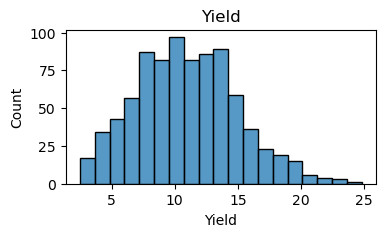

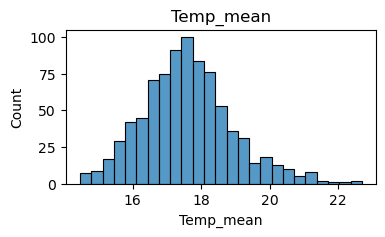

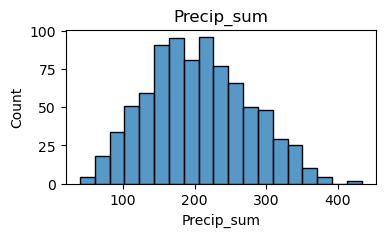

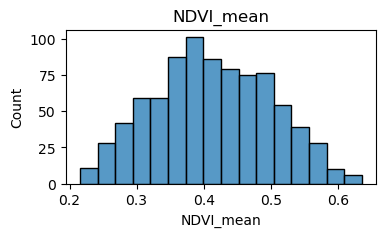

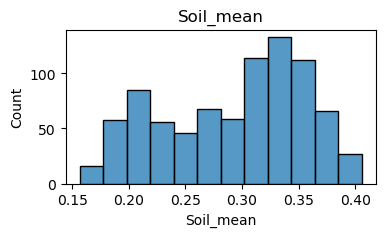

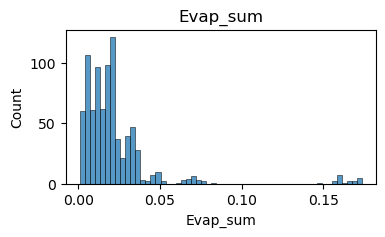

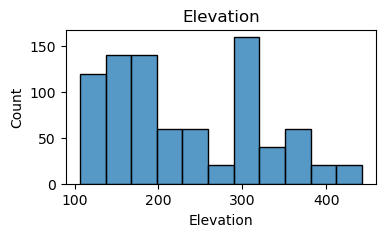

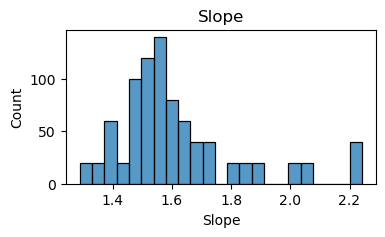

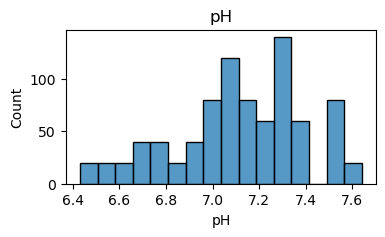

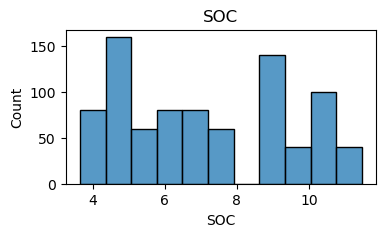

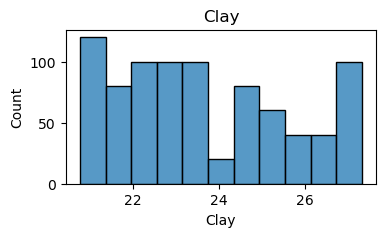

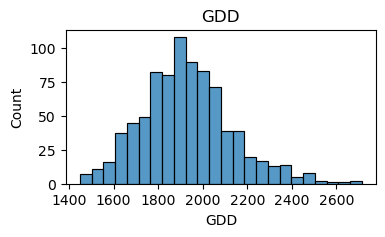

In [304]:
cols = ['Yield','Temp_mean','Precip_sum','NDVI_mean','Soil_mean','Evap_sum','Elevation','Slope','pH','SOC','Clay','GDD']
for col in cols:
    plt.figure(figsize=(4,2))
    sns.histplot(x=final_df[col])
    plt.title(col)
    plt.show()

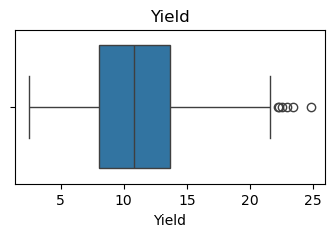

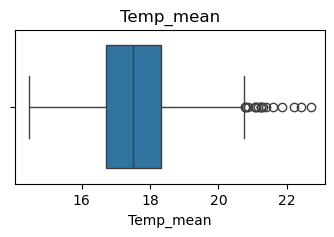

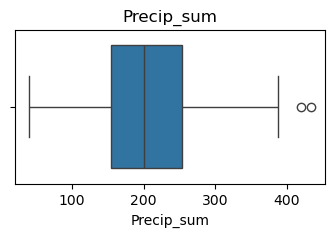

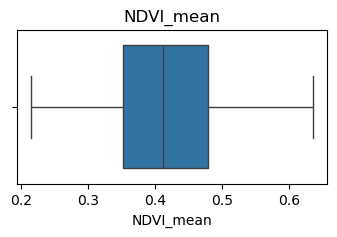

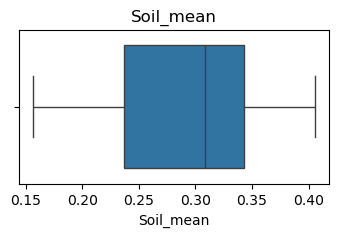

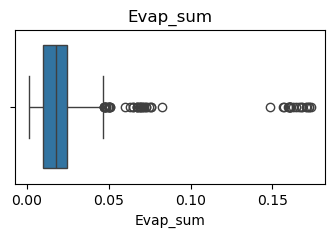

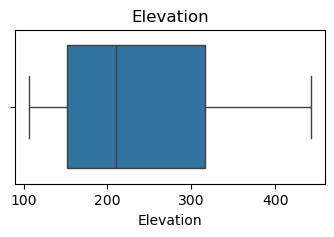

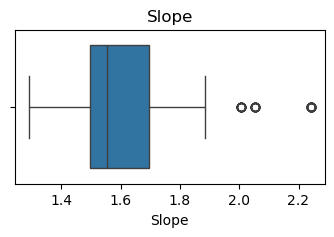

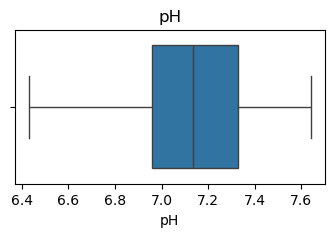

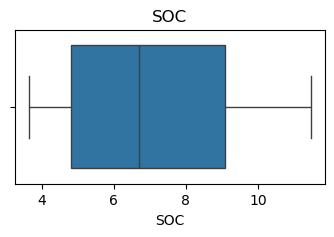

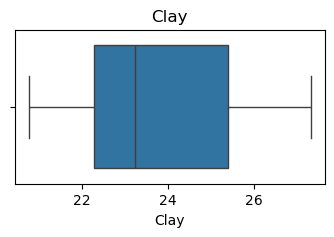

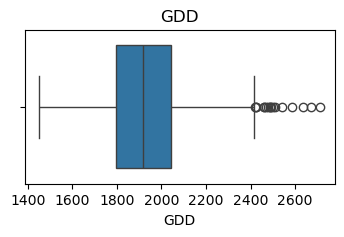

In [305]:
for col in cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=final_df[col])
    plt.title(col)
    plt.show()

<Axes: >

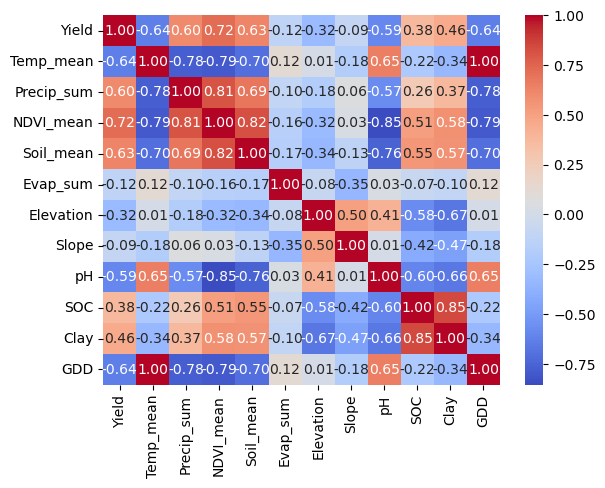

In [306]:
corr = final_df[cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')

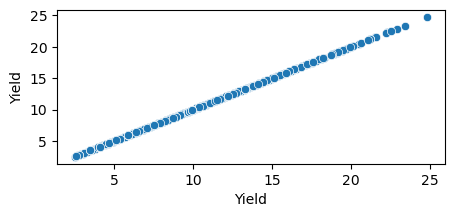

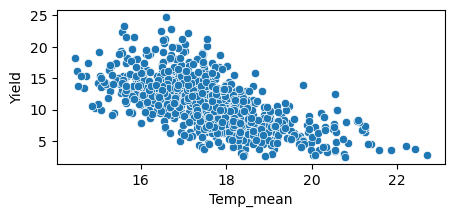

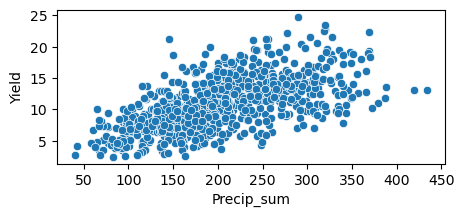

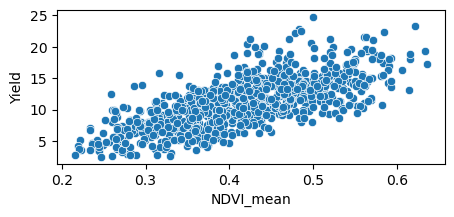

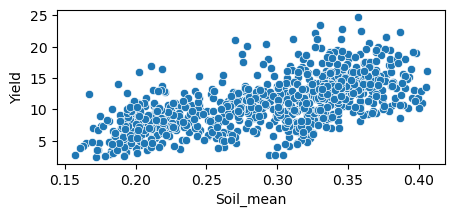

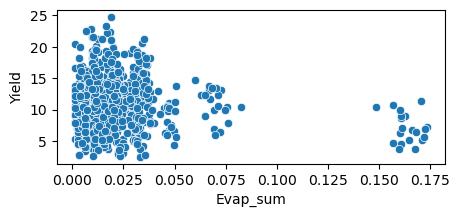

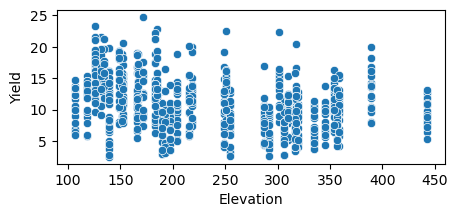

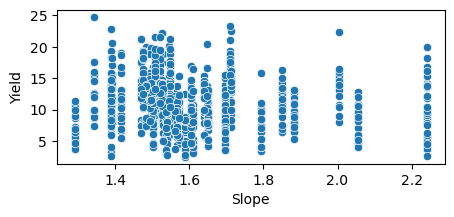

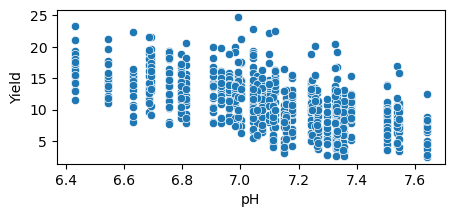

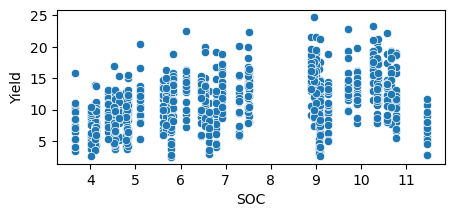

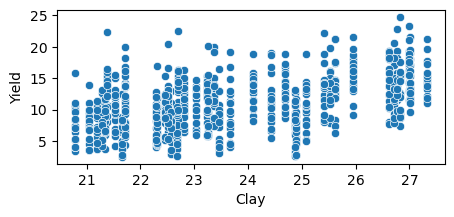

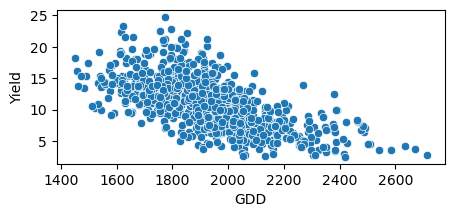

In [307]:
for col in cols:
    plt.figure(figsize=(5,2))
    sns.scatterplot(data=final_df, x=col, y='Yield')
    plt.show()

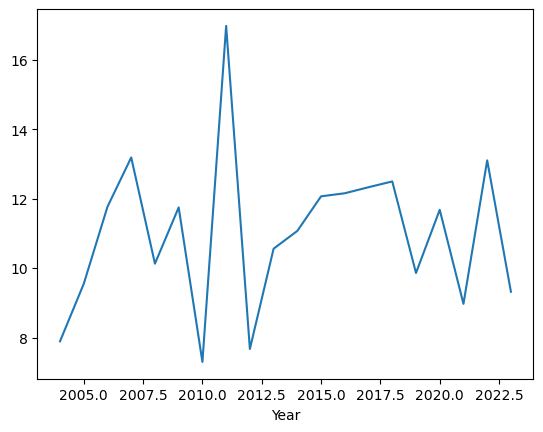

In [308]:
yield_year = final_df.groupby('Year')['Yield'].mean()
yield_year.plot()
plt.show()

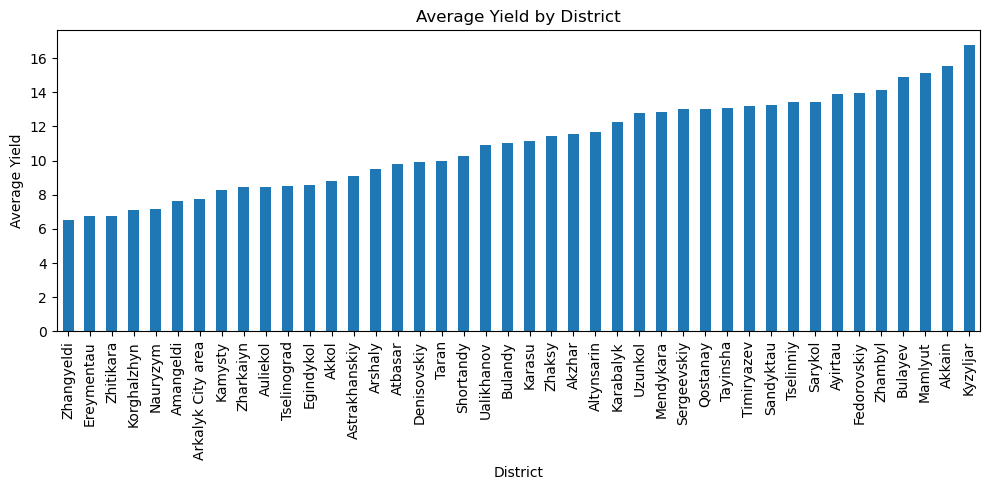

In [309]:
district_yield = (final_df.groupby('District')['Yield'].mean().sort_values())
district_yield.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel('Average Yield')
plt.title('Average Yield by District')
plt.tight_layout()
plt.show()

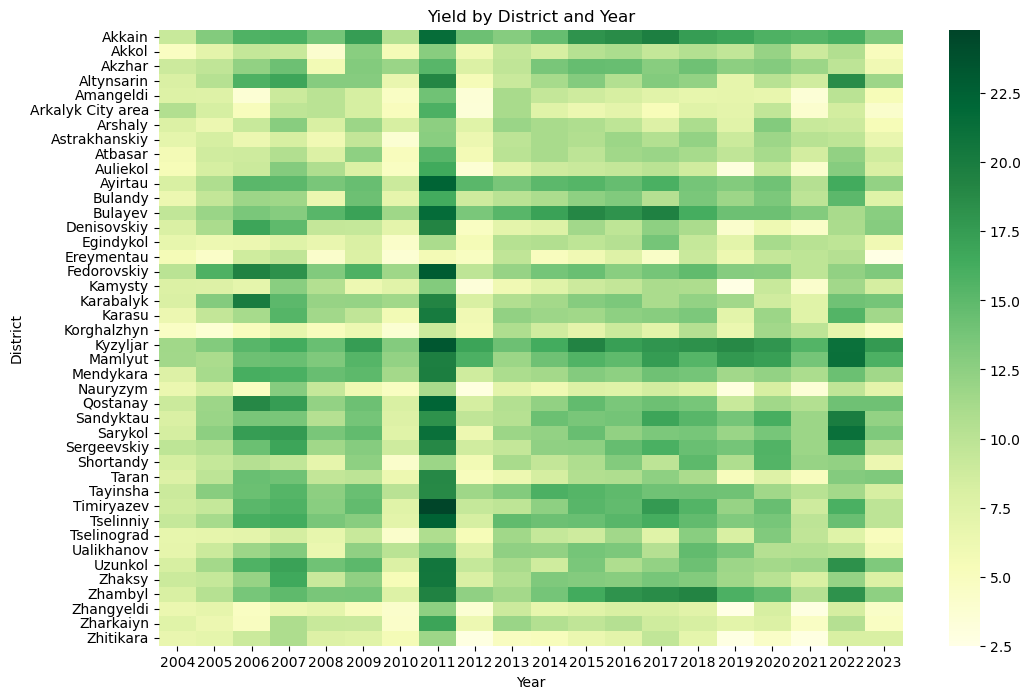

In [310]:
pivot = final_df.pivot_table(
    values='Yield',
    index='District',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    cmap='YlGn'
)

plt.title('Yield by District and Year')
plt.show()

In [311]:
final_df.describe()

,Year,Yield,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,EVI_5,EVI_6,EVI_7,...,Temp_min,Precip_sum,NDVI_mean,EVI_mean,Soil_mean,Evap_sum,NDVI_max,EVI_max,Soil_min,GDD
count,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,...,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000
mean,2013.500000,10.991071,0.383492,0.477276,0.494433,0.396962,0.311709,0.204566,0.274437,0.287594,...,12.653535,205.448034,0.412774,0.228780,0.293412,0.022366,0.517753,0.301426,0.264146,1930.458949
std,5.769717,4.029194,0.059320,0.109394,0.139806,0.112263,0.069789,0.034694,0.070179,0.092350,...,1.609955,70.551105,0.087236,0.052223,0.061821,0.025694,0.118821,0.081510,0.059875,203.189777
min,2004.000000,2.500000,0.238463,0.222459,0.196548,0.186594,0.179981,0.129189,0.133383,0.117738,...,8.406928,39.772476,0.215423,0.124757,0.156879,0.001120,0.282576,0.156511,0.147393,1448.846052
25%,2008.750000,8.075000,0.340884,0.394720,0.387287,0.309864,0.257860,0.179069,0.220592,0.214707,...,11.595134,154.558025,0.351624,0.189120,0.237069,0.009985,0.421821,0.235959,0.208611,1794.505134
50%,2013.500000,10.850000,0.377074,0.471338,0.495164,0.384155,0.304076,0.200072,0.265330,0.279738,...,12.737530,200.728010,0.411741,0.222997,0.308784,0.017746,0.512568,0.289266,0.285112,1917.124187
75%,2018.250000,13.700000,0.421199,0.556009,0.606636,0.476073,0.363001,0.225419,0.316914,0.359157,...,13.736798,254.411655,0.478527,0.265739,0.342796,0.024678,0.610508,0.363245,0.309853,2044.205521
max,2023.000000,24.800000,0.585780,0.752636,0.772995,0.678153,0.522930,0.359600,0.511979,0.513492,...,18.208425,433.810380,0.635848,0.386018,0.405723,0.173456,0.772995,0.513492,0.386124,2713.669244


In [73]:
features = ['Year', 'Elevation', 'Slope', 'pH', 'SOC', 'Clay',
       'Temp_mean', 'Temp_max', 'Temp_min', 'Precip_sum', 'NDVI_mean',
       'EVI_mean', 'Soil_mean', 'Evap_sum', 'NDVI_max', 'EVI_max', 'Soil_min','GDD']
features_raw = ['Year', 'NDVI_5', 'NDVI_6', 'NDVI_7', 'NDVI_8',
       'NDVI_9', 'EVI_5', 'EVI_6', 'EVI_7', 'EVI_8', 'EVI_9', 'Temp_5',
       'Temp_6', 'Temp_7', 'Temp_8', 'Temp_9', 'Precip_5', 'Precip_6',
       'Precip_7', 'Precip_8', 'Precip_9', 'Soil_5', 'Soil_6', 'Soil_7',
       'Soil_8', 'Soil_9', 'Evap_5', 'Evap_6', 'Evap_7', 'Evap_8', 'Evap_9',
       'Elevation', 'Slope', 'pH', 'SOC', 'Clay']

features = final_df[features]
features = features.columns.tolist()
features_raw = final_df[features_raw]
features_raw = features_raw.columns.tolist()

A

In [74]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final_df[features]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

      Variable            VIF
0        const  794950.564356
1         Year       1.359378
2    Elevation       2.435273
3        Slope       2.968385
4           pH       8.673401
5          SOC       4.528238
6         Clay       7.365998
7    Temp_mean   31542.827578
8     Temp_max       4.434922
9     Temp_min       4.665517
10  Precip_sum       5.555817
11   NDVI_mean     151.918944
12    EVI_mean     144.509818
13   Soil_mean      74.891613
14    Evap_sum       1.859730
15    NDVI_max     121.663998
16     EVI_max     118.746251
17    Soil_min      72.403934
18         GDD   31105.666933


In [75]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final_df[features_raw]

# Add intercept
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

     Variable            VIF
0       const  251422.421995
1        Year       1.939351
2      NDVI_5      49.389895
3      NDVI_6     129.925677
4      NDVI_7     136.914943
5      NDVI_8     134.910088
6      NDVI_9      65.953141
7       EVI_5      44.134012
8       EVI_6      91.870352
9       EVI_7     117.358155
10      EVI_8     105.708823
11      EVI_9      53.196668
12     Temp_5       2.913219
13     Temp_6       3.696682
14     Temp_7       3.513376
15     Temp_8       4.756165
16     Temp_9       2.937558
17   Precip_5       3.128787
18   Precip_6       5.337937
19   Precip_7       7.377210
20   Precip_8       8.997389
21   Precip_9       3.855289
22     Soil_5      50.072487
23     Soil_6     127.011191
24     Soil_7     176.041639
25     Soil_8     127.243579
26     Soil_9     126.786902
27     Evap_5      19.187418
28     Evap_6      77.473822
29     Evap_7      73.213366
30     Evap_8     126.935363
31     Evap_9      29.720348
32  Elevation       2.930810
33      Slope 

In [76]:
features = ['Year', 'Elevation', 'Slope', 'pH', 'SOC', 'Clay',
       'Temp_min','Temp_max', 'Precip_sum', 'NDVI_mean', 'Soil_mean', 'Evap_sum']

features = final_df[features]
features = features.columns.tolist()

In [77]:
X = final_df[features]
y = final_df['Yield']
scaler = StandardScaler()

train = final_df[final_df['Year'] <= 2019]
test = final_df[final_df['Year'] >= 2020]

X_train = train[features]
X_test = test[features]
y_train = train['Yield']
y_test = test['Yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final_df[features]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

      Variable            VIF
0        const  154970.331953
1         Year       1.193545
2    Elevation       2.256784
3        Slope       2.792338
4           pH       7.228464
5          SOC       4.314046
6         Clay       6.793210
7     Temp_min       1.821498
8     Temp_max       2.454216
9   Precip_sum       4.092620
10   NDVI_mean      10.891278
11   Soil_mean       4.347920
12    Evap_sum       1.704440


In [79]:
model_linear = LinearRegression()

model_linear.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
pred_linear = model_linear.predict(X_test_scaled)

In [81]:
r2_linear_score = r2_score(y_test, pred_linear)
mae_linear_score = mean_absolute_error(y_test, pred_linear)
rmse_linear_score = mean_squared_error(y_test, pred_linear)**0.5
print("R2 =", r2_linear_score)
print("MAE =", mae_linear_score)
print("RMSE =", rmse_linear_score)

R2 = 0.6039787650798163
MAE = 1.942981349175316
RMSE = 2.453013441906774


In [82]:
y_train_pred = model_linear.predict(X_train_scaled)
r2_train = r2_score(y_train, y_train_pred)

y_test_pred = model_linear.predict(X_test_scaled)
r2_test = r2_score(y_test, y_test_pred)

difference_l = r2_train - r2_test
print("Train R²:", round(r2_train, 4))
print("Test R²:", round(r2_test, 4))
print("Difference:", round(difference_l, 4))

Train R²: 0.5912
Test R²: 0.604
Difference: -0.0127


In [83]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

R²: 0.6209506666610702
MAE: 1.8842083333333335
RMSE: 2.399874658185298


In [84]:
y_train_pred_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train, y_train_pred_rf)

y_test_pred_rf = rf.predict(X_test)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
difference_rf = r2_train_rf - r2_test_rf
print("Train R²:", round(r2_train_rf, 4))
print("Test R²:", round(r2_test_rf, 4))
print("Difference:", round(difference_rf, 4))

Train R²: 0.9698
Test R²: 0.621
Difference: 0.3489


In [85]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb= xgb.predict(X_test)

r2_xg= r2_score(y_test, y_pred_xgb)
mae_xg= mean_absolute_error(y_test, y_pred_xgb)
rmse_xg= root_mean_squared_error(y_test, y_pred_xgb)
print("R²:", r2_xg)
print("MAE:", mae_xg)
print("RMSE:", rmse_xg)

R²: 0.5696562078495939
MAE: 1.951540382135482
RMSE: 2.557104417214792


In [86]:
y_train_pred_xg = xgb.predict(X_train)
r2_train_xg = r2_score(y_train, y_train_pred_xg)

y_test_pred_xg = xgb.predict(X_test)
r2_test_xg = r2_score(y_test, y_test_pred_xg)
difference_xg = r2_train_xg - r2_test_xg
print("Train R²:", round(r2_train_xg, 4))
print("Test R²:", round(r2_test_xg, 4))
print("Difference:", round(difference_xg, 4))

Train R²: 0.9999
Test R²: 0.5697
Difference: 0.4303


B


In [87]:
features_raw = ['Year','NDVI_7','NDVI_9', 'Temp_5',
       'Temp_6', 'Temp_7', 'Temp_8', 'Temp_9', 'Precip_5', 'Precip_6',
       'Precip_7', 'Precip_8', 'Precip_9', 
       'Elevation', 'Slope', 'pH', 'SOC', 'Clay']

features_raw = final_df[features_raw]
features_raw = features_raw.columns.tolist()

In [88]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final_df[features_raw]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

     Variable            VIF
0       const  171433.465752
1        Year       1.348849
2      NDVI_7       9.397293
3      NDVI_9       5.803558
4      Temp_5       2.146004
5      Temp_6       2.602245
6      Temp_7       2.842737
7      Temp_8       3.498512
8      Temp_9       2.154916
9    Precip_5       1.666448
10   Precip_6       2.090147
11   Precip_7       2.341087
12   Precip_8       3.790949
13   Precip_9       2.171654
14  Elevation       2.381668
15      Slope       1.933209
16         pH       5.966744
17        SOC       4.221204
18       Clay       5.774634


In [89]:
X_raw = final_df[features_raw]
y = final_df['Yield']
scaler = StandardScaler()

X_train_raw = train[features_raw]
X_test_raw = test[features_raw]
y_train = train['Yield']
y_test = test['Yield']

X_train_scaled_raw= scaler.fit_transform(X_train_raw)
X_test_scaled_raw = scaler.transform(X_test_raw)

model_linear.fit(X_train_scaled_raw, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [90]:
pred_raw = model_linear.predict(X_test_scaled_raw)
r2_raw = r2_score(y_test, pred_raw)
mae_raw = mean_absolute_error(y_test, pred_raw)
rmse_raw = mean_squared_error(y_test, pred_raw)**0.5
print("R2 =", r2_raw)
print("MAE =", mae_raw)
print("RMSE =", rmse_raw)

R2 = 0.753687905093946
MAE = 1.5249806775965027
RMSE = 1.934566041802284


In [91]:
train_pred_raw = model_linear.predict(X_train_scaled_raw)
r2_raw_train = r2_score(y_train, train_pred_raw)
test_pred_raw = model_linear.predict(X_test_scaled_raw)
r2_test_raw = r2_score(y_test, test_pred_raw)
difference_raw = r2_raw_train - r2_test_raw
print("Train R²:", round(r2_raw_train, 4))
print("Test R²:", round(r2_test_raw, 4))
print("Difference:", round(difference_raw, 4))

Train R²: 0.7891
Test R²: 0.7537
Difference: 0.0355


In [92]:
rf.fit(X_train_raw, y_train)
y_pred_rf_raw = rf.predict(X_test_raw)
r2_rf_raw= r2_score(y_test, y_pred_rf_raw)
mae_rf_raw = mean_absolute_error(y_test, y_pred_rf_raw)
rmse_rf_raw = root_mean_squared_error(y_test, y_pred_rf_raw)
print("R²:", r2_rf_raw)
print("MAE:", mae_rf_raw)
print("RMSE:", rmse_rf_raw)

R²: 0.6390738170050411
MAE: 1.9144285714285711
RMSE: 2.3418004520331905


In [93]:
train_rf_raw =rf.predict(X_train_raw)
r2_raw_rf_train = r2_score(y_train, train_rf_raw)
test_rf_raw = rf.predict(X_test_raw)
r2_test_raw_rf = r2_score(y_test, test_rf_raw)
difference_raw_rf = r2_raw_rf_train - r2_test_raw_rf
print("Train R²:", round(r2_raw_rf_train, 4))
print("Test R²:", round(r2_test_raw_rf, 4))
print("Difference:", round(difference_raw_rf, 4))

Train R²: 0.9758
Test R²: 0.6391
Difference: 0.3367


In [94]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train_raw, y_train)
y_pred_xgb_raw = xgb.predict(X_test_raw)

r2_xg_raw = r2_score(y_test, y_pred_xgb_raw)
mae_xg_raw = mean_absolute_error(y_test, y_pred_xgb_raw)
rmse_xg_raw = root_mean_squared_error(y_test, y_pred_xgb_raw)
print("R²:", r2_xg_raw)
print("MAE:", mae_xg_raw)
print("RMSE:", rmse_xg_raw)

R²: 0.6710467789527809
MAE: 1.8219975181988306
RMSE: 2.235670327826027


In [95]:
train_xg_raw =xgb.predict(X_train_raw)
r2_raw_xg_train = r2_score(y_train, train_xg_raw)
test_xg_raw = xgb.predict(X_test_raw)
r2_test_raw_xg = r2_score(y_test, test_xg_raw)
difference_raw_xg = r2_raw_xg_train - r2_test_raw_xg
print("Train R²:", round(r2_raw_xg_train, 4))
print("Test R²:", round(r2_test_raw_xg, 4))
print("Difference:", round(difference_raw_xg, 4))

Train R²: 1.0
Test R²: 0.671
Difference: 0.3289


In [96]:
results = pd.DataFrame([

# Aggregated
['Aggregated','Linear',r2_linear_score,mae_linear_score,rmse_linear_score, difference_l],
['Aggregated','Random Forest',r2_rf,mae_rf,rmse_rf, difference_rf],
['Aggregated','XGBoost',r2_xg,mae_xg,rmse_xg, difference_xg],

# Raw
['Raw','Linear',r2_raw,mae_raw,rmse_raw, difference_raw],
['Raw','Random Forest',r2_rf_raw,mae_rf_raw,rmse_rf_raw, difference_raw_rf],
['Raw','XGBoost',r2_xg_raw,mae_xg_raw,rmse_xg_raw, difference_raw_xg],

], columns=['Dataset','Model','R2','MAE','RMSE', 'Train - Test R2'])

results.sort_values('R2', ascending=False)

,Dataset,Model,R2,MAE,RMSE,Train - Test R2
3,Raw,Linear,0.753688,1.524981,1.934566,0.035453
5,Raw,XGBoost,0.671047,1.821998,2.235670,0.328933
4,Raw,Random Forest,0.639074,1.914429,2.341800,0.336713
1,Aggregated,Random Forest,0.620951,1.884208,2.399875,0.348858
0,Aggregated,Linear,0.603979,1.942981,2.453013,-0.012750
2,Aggregated,XGBoost,0.569656,1.951540,2.557104,0.430259


In [97]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]}
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42)
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    cv=tscv,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_raw, y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
0.4856445178649472


In [98]:
xgb = XGBRegressor(subsample= 0.7, n_estimators= 500, min_child_weight= 1, max_depth= 5, learning_rate= 0.05, gamma= 0.3, colsample_bytree= 0.8,random_state=42, n_jobs=-1)
xgb.fit(X_train_raw, y_train)
y_pred_xgb_raw = xgb.predict(X_test_raw)

r2_xg_raw = r2_score(y_test, y_pred_xgb_raw)
mae_xg_raw = mean_absolute_error(y_test, y_pred_xgb_raw)
rmse_xg_raw = root_mean_squared_error(y_test, y_pred_xgb_raw)
print("R²:", r2_xg_raw)
print("MAE:", mae_xg_raw)
print("RMSE:", rmse_xg_raw)

R²: 0.6605399896577329
MAE: 1.8321478662036716
RMSE: 2.271093431643886


In [99]:
best_xgb_train = xgb.predict(X_train_raw)
r2_best_xgb = r2_score(y_train, best_xgb_train)
best_xgb_test = xgb.predict(X_test_raw)
r2_best_xgb_test = r2_score(y_test, best_xgb_test)
difference_best_xgb = r2_best_xgb - r2_best_xgb_test
print("Train R²:", round(r2_best_xgb, 4))
print("Test R²:", round(r2_best_xgb_test, 4))
print("Difference:", round(difference_best_xgb, 4))

Train R²: 0.9958
Test R²: 0.6605
Difference: 0.3353


In [100]:
param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    scoring="r2",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_raw, y_train)

print("Best parameters:", search.best_params_)
print("Best CV R²:", search.best_score_)

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Best CV R²: 0.38036802336284464


In [101]:
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test_raw)
print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R²: 0.6467246305477345
MAE: 1.9054922117799482
RMSE: 2.3168470854736447


In [102]:
best_rf_train = best_rf.predict(X_train_raw)
r2_best_rf = r2_score(y_train, best_rf_train)
best_rf_test = best_rf.predict(X_test_raw)
r2_best_rf_test = r2_score(y_test, best_rf_test)
difference_best_rf = r2_best_rf - r2_best_rf_test
print("Train R²:", round(r2_best_rf, 4))
print("Test R²:", round(r2_best_rf_test, 4))
print("Difference:", round(difference_best_rf, 4))

Train R²: 0.9374
Test R²: 0.6467
Difference: 0.2907


In [103]:
importance = pd.DataFrame({
    'Feature': X_train_raw.columns,
    'Importance': best_rf.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

      Feature  Importance
1      NDVI_7    0.691038
7      Temp_9    0.072493
9    Precip_6    0.036205
0        Year    0.029344
8    Precip_5    0.018253
6      Temp_8    0.018194
16        SOC    0.016207
13  Elevation    0.015594
14      Slope    0.015376
5      Temp_7    0.011907
3      Temp_5    0.011850
11   Precip_8    0.011009
10   Precip_7    0.010328
2      NDVI_9    0.010007
4      Temp_6    0.009553
15         pH    0.009518
17       Clay    0.007085
12   Precip_9    0.006038


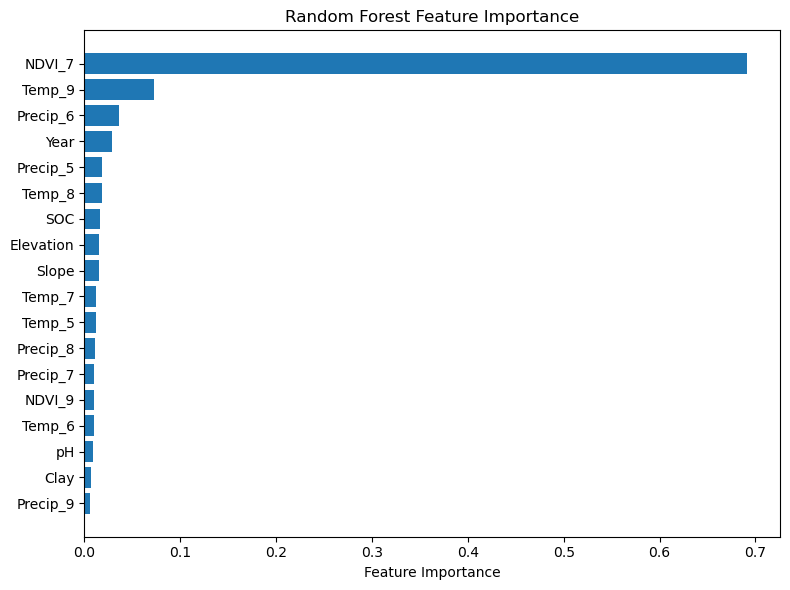

In [104]:
plt.figure(figsize=(8,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [105]:
importance = pd.DataFrame({
    'Feature': X_train_raw.columns,
    'Importance': xgb.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

      Feature  Importance
1      NDVI_7    0.311199
3      Temp_5    0.124245
7      Temp_9    0.065865
16        SOC    0.064129
0        Year    0.056871
15         pH    0.049714
9    Precip_6    0.047804
13  Elevation    0.040302
4      Temp_6    0.030233
5      Temp_7    0.030156
8    Precip_5    0.027402
14      Slope    0.026442
6      Temp_8    0.026047
10   Precip_7    0.025618
17       Clay    0.022648
11   Precip_8    0.019351
2      NDVI_9    0.018226
12   Precip_9    0.013748


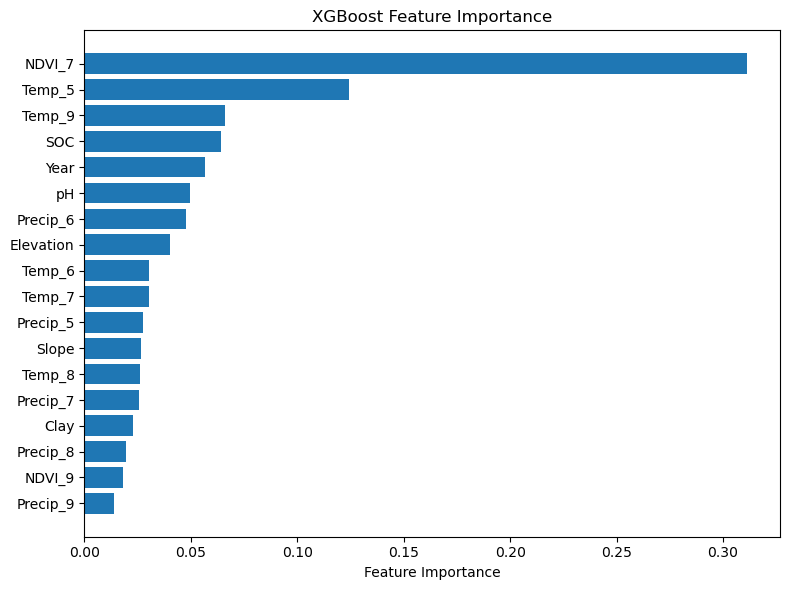

In [106]:
plt.figure(figsize=(8,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

The winning model - linear regression 

In [107]:
model_linear.fit(X_train_scaled_raw, y_train)
pred_raw = model_linear.predict(X_test_scaled_raw)
r2_raw = r2_score(y_test, pred_raw)
mae_raw = mean_absolute_error(y_test, pred_raw)
rmse_raw = mean_squared_error(y_test, pred_raw)**0.5
print("R2 =", r2_raw)
print("MAE =", mae_raw)
print("RMSE =", rmse_raw)

R2 = 0.753687905093946
MAE = 1.5249806775965027
RMSE = 1.934566041802284


In [108]:
coef_df = pd.DataFrame({'Feature':X_train_raw.columns,
                       'Coefficient': model_linear.coef_})
coef_df = coef_df.sort_values(by='Coefficient',key=abs,ascending=False)
print(coef_df)

      Feature  Coefficient
1      NDVI_7     3.709861
2      NDVI_9    -1.581424
13  Elevation    -0.987075
7      Temp_9     0.835442
6      Temp_8    -0.455761
0        Year     0.434798
17       Clay    -0.417455
4      Temp_6    -0.389467
12   Precip_9     0.372420
8    Precip_5     0.307229
16        SOC     0.276401
5      Temp_7    -0.275034
11   Precip_8     0.175339
3      Temp_5     0.152582
9    Precip_6     0.139741
15         pH     0.104135
10   Precip_7    -0.064558
14      Slope     0.020177


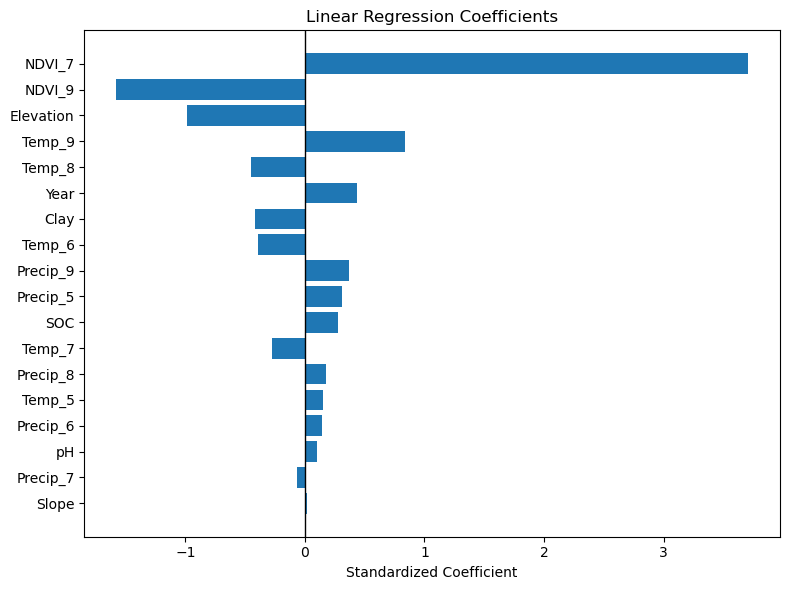

In [109]:
plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()

plt.xlabel("Standardized Coefficient")
plt.title("Linear Regression Coefficients")

plt.tight_layout()
plt.show()

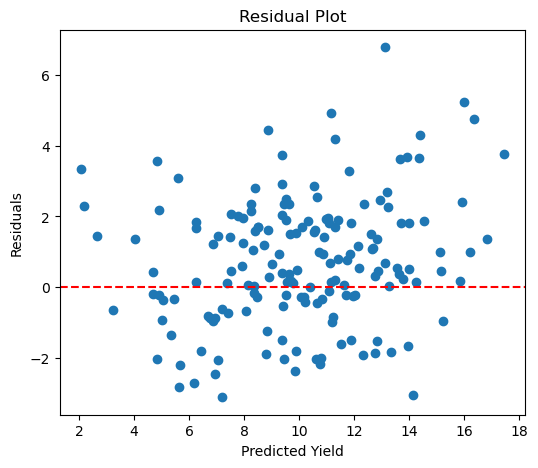

In [110]:
residuals = y_test - pred_raw

plt.figure(figsize=(6,5))
plt.scatter(pred_raw, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

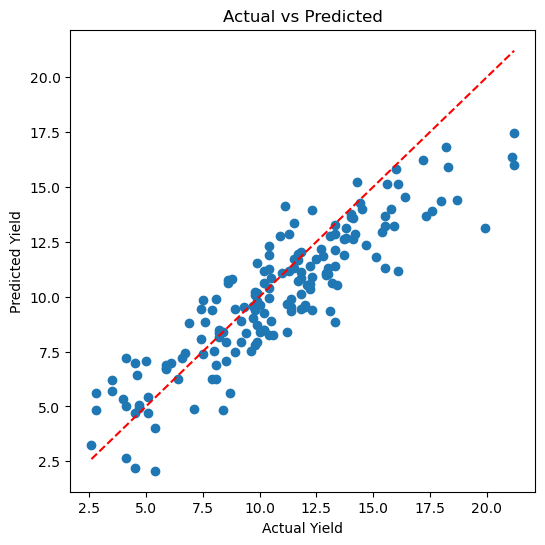

In [111]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_raw)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted")
plt.show()

In [206]:
import statsmodels.api as sm
X_sm = pd.DataFrame(
    X_train_scaled,
    columns=X_train_raw.columns
).reset_index(drop=True)

X_sm = sm.add_constant(X_sm)

y_sm = y_train.reset_index(drop=True)

ols = sm.OLS(y_sm, X_sm).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     123.7
Date:                Sat, 04 Jul 2026   Prob (F-statistic):          2.35e-167
Time:                        01:27:37   Log-Likelihood:                -961.20
No. Observations:                 500   AIC:                             1960.
Df Residuals:                     481   BIC:                             2040.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.5244      0.075    152.770      0.0

In [257]:
features_raw2 = ['Year','NDVI_7','NDVI_9', 'Temp_5',
       'Temp_6', 'Temp_8', 'Temp_9', 'Precip_5',
       'Elevation']

features_raw2 = final_df[features_raw2]
features_raw2 = features_raw2.columns.tolist()

In [258]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final_df[features_raw2]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

    Variable            VIF
0      const  162104.207388
1       Year       1.299012
2     NDVI_7       3.575665
3     NDVI_9       2.288946
4     Temp_5       1.939965
5     Temp_6       2.203125
6     Temp_8       2.217449
7     Temp_9       1.410310
8   Precip_5       1.407848
9  Elevation       1.281089


In [259]:
X_raw = final_df[features_raw2]
y = final_df['Yield']
scaler = StandardScaler()

X_train_raw = train[features_raw2]
X_test_raw = test[features_raw2]
y_train = train['Yield']
y_test = test['Yield']

X_train_scaled_raw= scaler.fit_transform(X_train_raw)
X_test_scaled_raw = scaler.transform(X_test_raw)

model_linear.fit(X_train_scaled_raw, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [260]:
pred_raw = model_linear.predict(X_test_scaled_raw)
r2_raw = r2_score(y_test, pred_raw)
mae_raw = mean_absolute_error(y_test, pred_raw)
rmse_raw = mean_squared_error(y_test, pred_raw)**0.5
print("R2 =", r2_raw)
print("MAE =", mae_raw)
print("RMSE =", rmse_raw)

R2 = 0.7648544416598021
MAE = 1.4994605363208569
RMSE = 1.8902057548803992


In [261]:
import statsmodels.api as sm
X_sm = pd.DataFrame(
    X_train_scaled_raw,
    columns=X_train_raw.columns
).reset_index(drop=True)

X_sm = sm.add_constant(X_sm)

y_sm = y_train.reset_index(drop=True)

ols = sm.OLS(y_sm, X_sm).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     262.9
Date:                Sat, 04 Jul 2026   Prob (F-statistic):          6.60e-212
Time:                        01:39:09   Log-Likelihood:                -1383.7
No. Observations:                 672   AIC:                             2787.
Df Residuals:                     662   BIC:                             2832.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.0469      0.074    149.862      0.0

In [262]:
train_pred_raw = model_linear.predict(X_train_scaled_raw)
r2_raw_train = r2_score(y_train, train_pred_raw)
test_pred_raw = model_linear.predict(X_test_scaled_raw)
r2_test_raw = r2_score(y_test, test_pred_raw)
difference_raw = r2_raw_train - r2_test_raw
print("Train R²:", round(r2_raw_train, 4))
print("Test R²:", round(r2_test_raw, 4))
print("Difference:", round(difference_raw, 4))

Train R²: 0.7814
Test R²: 0.7649
Difference: 0.0165


In [263]:
coef_df = pd.DataFrame({'Feature':X_train_raw.columns,
                       'Coefficient': model_linear.coef_})
coef_df = coef_df.sort_values(by='Coefficient',key=abs,ascending=False)
print(coef_df)

     Feature  Coefficient
1     NDVI_7     3.862416
2     NDVI_9    -1.527300
8  Elevation    -0.870107
6     Temp_9     0.817821
5     Temp_8    -0.623229
0       Year     0.514129
4     Temp_6    -0.459991
3     Temp_5     0.220156
7   Precip_5     0.209912


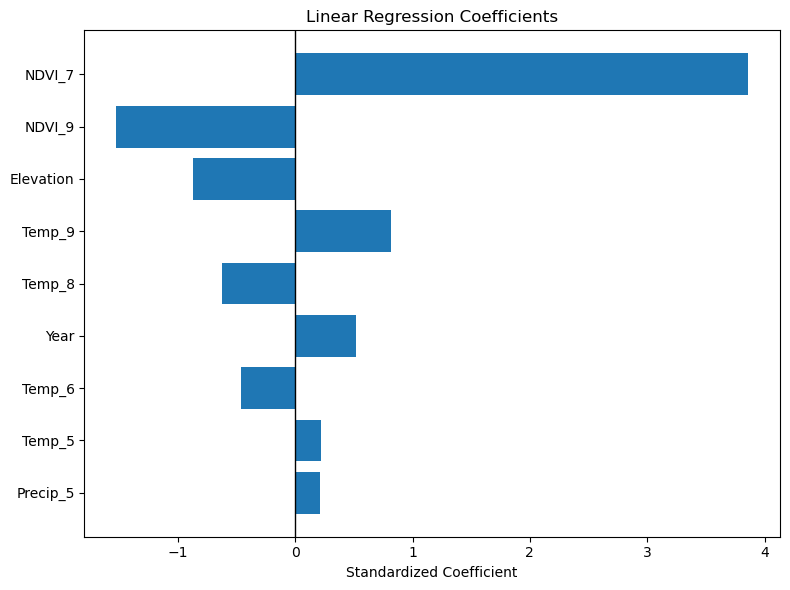

In [264]:
plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()

plt.xlabel("Standardized Coefficient")
plt.title("Linear Regression Coefficients")

plt.tight_layout()
plt.show()

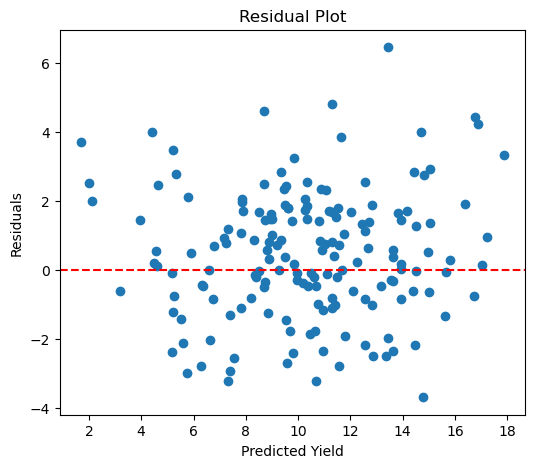

In [265]:
residuals = y_test - pred_raw

plt.figure(figsize=(6,5))
plt.scatter(pred_raw, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

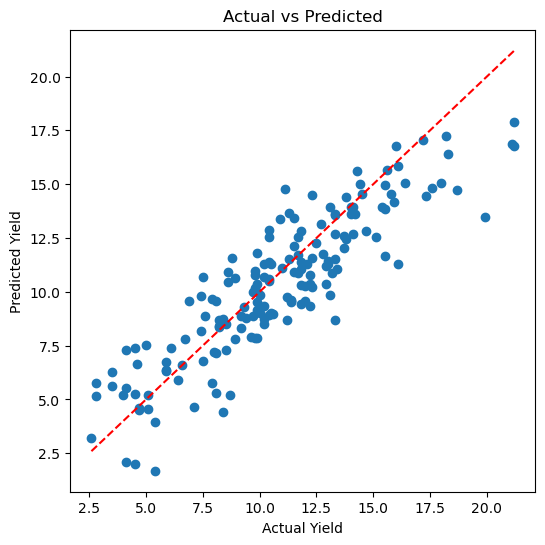

In [266]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_raw)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted")
plt.show()

In [113]:
#Turkestan
turkestan = pd.read_csv('turkestan.csv')
turkestan

,Unnamed: 0,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,г.Шымкент,10.3,10.2,7.4,6.6,5.5,9.1,5.4,4.3,6.1,...,13.6,10.8,-,-,-,-,-,-,-,-
1,г.Туркестан,30.0,22.9,24.5,24.1,12.5,34.6,24.4,25.9,32.9,...,34.0,36.5,48.5,-,-,-,-,-,-,-
2,г.а.Арысь,17.4,16.2,15.8,15.2,8.5,13.2,13.0,7.4,9.5,...,28.8,20.9,12.5,15.4,13.3,9.0,15.4,11.2,14.9,9.7
3,г.а.Кентау,16.2,12.8,12.6,13.4,11.5,19.6,14.8,11.9,12.6,...,23.7,24.3,29.5,34.8,35.0,22.8,23.4,33.2,32.4,10.9
4,район Байдибек,16.7,13.5,9.9,16.2,9.7,18.4,12.6,14.2,7.8,...,18.2,16.1,11.3,19.6,18.7,9.2,14.2,14.2,17.9,8.9
5,Жетысайский,-,-,-,-,-,-,-,-,-,...,-,-,47.9,47.4,49.7,52.9,54.0,54.6,53.5,43.4
6,Келесский,-,-,-,-,-,-,-,-,-,...,-,-,39.0,37.7,41.1,40.6,42.9,37.6,34.5,30.6
7,Казыгуртский,20.3,14.6,13.9,15.6,9.3,19.1,17.4,18.2,13.8,...,24.1,16.8,15.5,18.4,16.7,16.8,21.3,21.6,21.5,23.1
8,Мактааральский,33.0,32.3,33.6,33.7,31.4,33.1,32.9,35.6,48.3,...,46.4,45.3,49.5,49.5,52.3,53.4,51.0,53.1,51.9,52.4
9,Ордабасынский,20.1,15.0,13.1,15.8,13.0,24.1,16.8,13.6,13.2,...,27.3,22.0,21.0,27.7,35.1,38.9,34.0,33.7,37.1,24.8


In [114]:
turkestan = turkestan.replace('-', np.nan)

In [115]:
turkestan = turkestan.rename(columns={'Unnamed: 0': 'District'})
turkestan = pd.melt(turkestan, id_vars='District', var_name='Year', value_name='Yield')
turkestan['Year'] = pd.to_numeric(turkestan['Year'])
turkestan= turkestan[(turkestan['Year'] >= 2004)&(turkestan['Year'] <= 2023)]
turkestan

,District,Year,Yield
0,г.Шымкент,2004,10.3
1,г.Туркестан,2004,30.0
2,г.а.Арысь,2004,17.4
3,г.а.Кентау,2004,16.2
4,район Байдибек,2004,16.7
...,...,...,...
355,Сауранский,2023,45.3
356,Сузакский,2023,21.9
357,Толебийский,2023,19.4
358,Тюлькубасский,2023,18.8


In [116]:
turkestan.isna().sum()

District     0
Year         0
Yield       55
dtype: int64

In [117]:
turkestan.groupby('Year')['Yield'].count()

Year
2004    15
2005    15
2006    15
2007    15
2008    15
2009    15
2010    15
2011    15
2012    15
2013    15
2014    15
2015    15
2016    15
2017    15
2018    16
2019    15
2020    16
2021    16
2022    16
2023    16
Name: Yield, dtype: int64

In [118]:
turkestan = turkestan.dropna()

In [119]:
months = [5, 6, 7, 8, 9]
def calc_ndvi_year(year):
    def add_ndvi(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            ndvi = (
                ee.ImageCollection('MODIS/061/MOD13Q1')
                .filterDate(start, end)
                .select('NDVI')
                .median()
                .multiply(0.0001)
            )
            value = ndvi.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=250,
                maxPixels=1e13
            ).get('NDVI')
            result = result.set(f'NDVI_{m}', value)
        return result.set('year', year)
    return turkestan_regions.map(add_ndvi)
    
turkestan_regions = kz_regions.filter(
    ee.Filter.inList(
        'ADM1_NAME',
        [
            'Yujno-kazachstanskaya'
        ]
    )
)
final_ndvi = calc_ndvi_year(2002)

for y in range(2003, 2024):
    final_ndvi = final_ndvi.merge(calc_ndvi_year(y))

In [120]:
#task = ee.batch.Export.table.toDrive(collection=final_ndvi,description='NDVI_turkestan',fileFormat='CSV')
#task.start()

In [121]:
turkestan_ndvi = pd.read_csv('NDVI_turkestan.csv')
turkestan_ndvi.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37309,Arys,NO,3000,0.377477,0.244805,0.215730,0.206407,0.197069,Member State,1000,0.696550,7.599018,2002,"{""type"":""Polygon"",""coordinates"":[[[66.81230300..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37310,Baydibek,NO,3000,0.551114,0.397967,0.291665,0.258574,0.235435,Member State,1000,0.789887,5.333954,2002,"{""type"":""Polygon"",""coordinates"":[[[69.44509897..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37311,Kazygurt,NO,3000,0.617401,0.451980,0.354003,0.306523,0.257340,Member State,1000,0.430572,5.041795,2002,"{""type"":""Polygon"",""coordinates"":[[[70.36844048..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37312,Maktaral,NO,3000,0.238300,0.316714,0.504997,0.587066,0.495023,Member State,1000,0.170777,1.973481,2002,"{""type"":""Polygon"",""coordinates"":[[[68.45599448..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37313,Ordabasy,NO,3000,0.562010,0.360116,0.331045,0.319939,0.283822,Member State,1000,0.305331,4.339813,2002,"{""type"":""MultiPolygon"",""coordinates"":[[[[69.16..."


In [122]:
years = list(range(2003, 2024))
months = [5, 6, 7, 8, 9]
def calc_temp_year(year):
    def add_temp(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('temperature_2m')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('temperature_2m')

            result = result.set(
                f'Temp_{m}',
                value)
        return result.set('Year', year)
    return turkestan_regions.map(add_temp)
final_temp = calc_temp_year(2000)
for y in range(2003, 2024):
    final_temp = final_temp.merge(calc_temp_year(y))

In [123]:
#task = ee.batch.Export.table.toDrive(collection=final_temp,description='turkestan_weather',fileFormat='CSV')
#task.start()

In [124]:
turkestan_weather = pd.read_csv('turkestan_weather.csv')
turkestan_weather.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Temp_5,Temp_6,Temp_7,Temp_8,Temp_9,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37309,Arys,NO,3000,Member State,1000,0.696550,7.599018,296.337334,301.269657,303.941442,303.319773,295.561321,2000,"{""type"":""Polygon"",""coordinates"":[[[66.81230300..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37310,Baydibek,NO,3000,Member State,1000,0.789887,5.333954,292.918542,297.706428,300.386526,299.919826,292.843062,2000,"{""type"":""Polygon"",""coordinates"":[[[69.44509897..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37311,Kazygurt,NO,3000,Member State,1000,0.430572,5.041795,289.670553,293.435248,296.401082,296.256718,290.352983,2000,"{""type"":""Polygon"",""coordinates"":[[[70.36844048..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37312,Maktaral,NO,3000,Member State,1000,0.170777,1.973481,297.452832,301.134775,303.251242,302.242580,296.080509,2000,"{""type"":""Polygon"",""coordinates"":[[[68.45599448..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37313,Ordabasy,NO,3000,Member State,1000,0.305331,4.339813,294.692421,299.859258,302.777676,302.246983,294.814648,2000,"{""type"":""MultiPolygon"",""coordinates"":[[[[69.16..."


In [125]:
years = list(range(2003, 2024))
months = [5, 6, 7, 8, 9]
def calc_prec_year(year):
    def add_prec(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('total_precipitation_sum')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('total_precipitation_sum')
            result = result.set(
                f'Precip_{m}',
                value
            )
        return result.set('year', year)
    return turkestan_regions.map(add_prec)
    
final_prec = calc_prec_year(2003)
for y in range(2003, 2024):
    final_prec = final_prec.merge(calc_prec_year(y))

In [126]:
#task = ee.batch.Export.table.toDrive(collection=final_prec,description='Precipitation_turkestan',fileFormat='CSV')
#task.start()

In [127]:
turkestan_prec = pd.read_csv('Precipitation_turkestan.csv')
turkestan_prec.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,Precip_5,Precip_6,Precip_7,Precip_8,Precip_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37309,Arys,NO,3000,0.095433,0.038546,0.003615,0.000330,0.001127,Member State,1000,0.696550,7.599018,2003,"{""type"":""Polygon"",""coordinates"":[[[66.81230300..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37310,Baydibek,NO,3000,0.145915,0.060380,0.021583,0.003755,0.002588,Member State,1000,0.789887,5.333954,2003,"{""type"":""Polygon"",""coordinates"":[[[69.44509897..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37311,Kazygurt,NO,3000,0.170520,0.089884,0.025426,0.014553,0.010113,Member State,1000,0.430572,5.041795,2003,"{""type"":""Polygon"",""coordinates"":[[[70.36844048..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37312,Maktaral,NO,3000,0.093456,0.039616,0.000389,0.000615,0.003879,Member State,1000,0.170777,1.973481,2003,"{""type"":""Polygon"",""coordinates"":[[[68.45599448..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37313,Ordabasy,NO,3000,0.139320,0.059874,0.009807,0.001435,0.001979,Member State,1000,0.305331,4.339813,2003,"{""type"":""MultiPolygon"",""coordinates"":[[[[69.16..."


In [128]:
years = list(range(2003, 2024))
months = [5, 6, 7, 8, 9]
def calc_soil_year(year):
    def add_soil(feature):
        result = feature.set('Year', year)
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .first())
            soil = (
                img.select('volumetric_soil_water_layer_1').multiply(7)
                .add(img.select('volumetric_soil_water_layer_2').multiply(21))
                .add(img.select('volumetric_soil_water_layer_3').multiply(72))
                .divide(100)
                .rename(f'Soil_{m}'))

            value = soil.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=1000,
                maxPixels=1e13
            ).get(f'Soil_{m}')
            result = result.set(f'Soil_{m}', value)
        return result
    return turkestan_regions.map(add_soil)
    
final_soil = calc_soil_year(2003)
for y in range(2003, 2024):
    final_soil = final_soil.merge(calc_soil_year(y))

In [129]:
#task = ee.batch.Export.table.toDrive(collection=final_soil,description='Soil_turkestan',fileFormat='CSV')
#task.start()

In [130]:
turkestan_soil = pd.read_csv('Soil_turkestan.csv')
turkestan_soil.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Soil_5,Soil_6,Soil_7,Soil_8,Soil_9,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37309,Arys,NO,3000,Member State,1000,0.696550,7.599018,0.301894,0.290939,0.243544,0.226400,0.219306,2003,"{""type"":""Polygon"",""coordinates"":[[[66.81230300..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37310,Baydibek,NO,3000,Member State,1000,0.789887,5.333954,0.369675,0.354335,0.265815,0.216662,0.195008,2003,"{""type"":""Polygon"",""coordinates"":[[[69.44509897..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37311,Kazygurt,NO,3000,Member State,1000,0.430572,5.041795,0.400461,0.379771,0.289217,0.239367,0.219619,2003,"{""type"":""Polygon"",""coordinates"":[[[70.36844048..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37312,Maktaral,NO,3000,Member State,1000,0.170777,1.973481,0.325844,0.284139,0.198729,0.165443,0.156912,2003,"{""type"":""Polygon"",""coordinates"":[[[68.45599448..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_0001...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37313,Ordabasy,NO,3000,Member State,1000,0.305331,4.339813,0.350020,0.344317,0.252717,0.208111,0.190313,2003,"{""type"":""MultiPolygon"",""coordinates"":[[[[69.16..."


In [131]:
def add_ph(feature):
    ph = ee.Image("OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02")
    ph_weighted = (
        ph.select('b0').multiply(5)
        .add(ph.select('b10').multiply(10))
        .add(ph.select('b30').multiply(15))
        .divide(30)
        .divide(10)
        .rename('pH'))
    value = ph_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('pH')
    return feature.set('pH', value)
ph_fc = turkestan_regions.map(add_ph)
turkestan_ph_df = geemap.ee_to_df(ph_fc)

In [132]:
def add_soc(feature):
    soc = ee.Image("OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02")
    soc_weighted = (
        soc.select('b0').multiply(5)
        .add(soc.select('b10').multiply(10))
        .add(soc.select('b30').multiply(15))
        .divide(30)
        .rename('SOC'))
    value = soc_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('SOC')
    return feature.set('SOC', value)
soc_fc = turkestan_regions.map(add_soc)
turkestan_soc_df = geemap.ee_to_df(soc_fc)

In [133]:
def add_clay(feature):
    clay = ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
    clay_weighted = (
        clay.select('b0').multiply(5)
        .add(clay.select('b10').multiply(10))
        .add(clay.select('b30').multiply(15))
        .divide(30)
        .rename('Clay'))
    value = clay_weighted.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=250,
        maxPixels=1e13
    ).get('Clay')
    return feature.set('Clay', value)
clay_fc = turkestan_regions.map(add_clay)
turkestan_clay_df = geemap.ee_to_df(clay_fc)

In [134]:
years = list(range(2000, 2026))
months = [5, 6, 7, 8, 9]
def calc_evap_year(year):
    def add_evap(feature):
        result = feature
        for m in months:
            start = ee.Date.fromYMD(year, m, 1)
            end = start.advance(1, 'month')
            img = (
                ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(start, end)
                .select('evaporation_from_vegetation_transpiration_sum')
                .sum()
            )
            value = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=feature.geometry(),
                scale=10000,
                maxPixels=1e13
            ).get('evaporation_from_vegetation_transpiration_sum')
            result = result.set(
                f'Evap_{m}',
                value
            )
        return result.set('Year', year)
    return turkestan_regions.map(add_evap)

final_evap = calc_evap_year(2000)
for y in range(2001, 2026):
    final_evap = final_evap.merge(calc_evap_year(y))

In [135]:
#task = ee.batch.Export.table.toDrive(collection=final_evap,description='Evap_turkestan',fileFormat='CSV')
#task.start()

In [136]:
turkestan_evap = pd.read_csv('Evap_turkestan.csv')
turkestan_evap.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,Evap_5,Evap_6,Evap_7,Evap_8,Evap_9,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,Year,.geo
0,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37309,Arys,NO,3000,-0.001307,-0.001553,-0.001845,-0.001803,-0.001265,Member State,1000,0.696550,7.599018,2000,"{""type"":""Polygon"",""coordinates"":[[[66.81230300..."
1,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37310,Baydibek,NO,3000,-0.000623,-0.000785,-0.000909,-0.000903,-0.000622,Member State,1000,0.789887,5.333954,2000,"{""type"":""Polygon"",""coordinates"":[[[69.44509897..."
2,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37311,Kazygurt,NO,3000,-0.000010,-0.000028,-0.000043,-0.000049,-0.000049,Member State,1000,0.430572,5.041795,2000,"{""type"":""Polygon"",""coordinates"":[[[70.36844048..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37312,Maktaral,NO,3000,-0.003650,-0.004150,-0.004612,-0.004123,-0.003214,Member State,1000,0.170777,1.973481,2000,"{""type"":""Polygon"",""coordinates"":[[[68.45599448..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_...,132,Kazakhstan,1728,Yujno-kazachstanskaya,37313,Ordabasy,NO,3000,-0.002038,-0.002594,-0.002981,-0.002968,-0.002107,Member State,1000,0.305331,4.339813,2000,"{""type"":""MultiPolygon"",""coordinates"":[[[[69.16..."


In [137]:
srtm = ee.Image('USGS/SRTMGL1_003')
def add_elevation(feature):
    elevation = srtm.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e13
    ).get('elevation')

    return feature.set('Elevation', elevation)

elevation_fc = turkestan_regions.map(add_elevation)

In [138]:
terrain = ee.Terrain.products(srtm)
slope = terrain.select('slope')

def add_slope(feature):
    slope_mean = slope.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e13
    ).get('slope')

    return feature.set('Slope', slope_mean)

slope_fc = elevation_fc.map(add_slope)

In [139]:
turkestan_elev_df = geemap.ee_to_df(elevation_fc)
turkestan_terrain_df = geemap.ee_to_df(slope_fc)

In [140]:
rename_dict = {
    'г.Шымкент': 'Shymkent City area',
    'г.Туркестан ': 'Turkestan City area',
    'г.а.Арысь ': 'Arys',
    'г.а.Кентау ': 'Kentau',
    'район Байдибек': 'Baydibek',
    'Казыгуртский ': 'Kazygurt',
    'Мактааральский ': 'Maktaral',
    'Ордабасынский ': 'Ordabasy',
    'Отрарский ': 'Otrar',
    'Сайрамский ': 'Sayram',
    'Сарыагашский': 'Saryaghash',
    'Сузакский ': 'Suzak',
    'Толебийский ': 'Tolebi',
    'Тюлькубасский ': 'Tulkibas',
    'Шардаринский ': 'Shardara',
    'Жетысайский': 'Zhetysai',
    'Келесский': 'Keles',
    'Сауранский': 'Sauran'}

In [141]:
turkestan['District'] = turkestan['District'].replace(rename_dict)
turkestan

/var/folders/c1/wzq4fr5d1sl83wscpxfqjj_00000gn/T/ipykernel_8346/3961101679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  turkestan['District'] = turkestan['District'].replace(rename_dict)


,District,Year,Yield
0,Shymkent City area,2004,10.3
1,Turkestan City area,2004,30.0
2,Arys,2004,17.4
3,Kentau,2004,16.2
4,Baydibek,2004,16.7
...,...,...,...
355,Sauran,2023,45.3
356,Suzak,2023,21.9
357,Tolebi,2023,19.4
358,Tulkibas,2023,18.8


In [142]:
turkestan_ndvi=turkestan_ndvi.drop(columns=['system:index','ADM0_CODE','ADM0_NAME', 'ADM1_CODE','ADM1_NAME', 'ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'])
turkestan_ndvi = turkestan_ndvi.rename(columns={'ADM2_NAME': 'District'})

turkestan_weather = turkestan_weather.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
turkestan_weather = turkestan_weather.rename(columns={'ADM2_NAME': 'District'})

turkestan_prec = turkestan_prec.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
turkestan_prec = turkestan_prec.rename(columns={'ADM2_NAME': 'District'})

turkestan_soil = turkestan_soil.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
turkestan_soil = turkestan_soil.rename(columns={'ADM2_NAME': 'District'})

turkestan_ph_df = turkestan_ph_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
turkestan_ph_df = turkestan_ph_df.rename(columns={'ADM2_NAME': 'District'})

turkestan_soc_df = turkestan_soc_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
turkestan_soc_df = turkestan_soc_df.rename(columns={'ADM2_NAME': 'District'})

turkestan_clay_df = turkestan_clay_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
turkestan_clay_df = turkestan_clay_df.rename(columns={'ADM2_NAME': 'District'})

turkestan_evap = turkestan_evap.drop(columns={'system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', '.geo'})
turkestan_evap = turkestan_evap.rename(columns={'ADM2_NAME': 'District'})

turkestan_terrain_df = turkestan_terrain_df.drop(columns={'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE','ADM1_NAME','ADM2_CODE', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng'})
turkestan_terrain_df = turkestan_terrain_df.rename(columns={'ADM2_NAME': 'District'})

In [143]:
turkestan_ndvi = turkestan_ndvi.rename(columns={'year': 'Year'})
turkestan_prec = turkestan_prec.rename(columns={'year': 'Year'})

In [144]:
turkestan_df = turkestan.merge(turkestan_weather,on=['District', 'Year'],how='inner')
turkestan_df = turkestan_df.merge(turkestan_ndvi,on=['District', 'Year'],how='inner')
turkestan_df = turkestan_df.merge(turkestan_prec,on=['District', 'Year'],how='inner')
turkestan_df = turkestan_df.merge(turkestan_soil,on=['District', 'Year'],how='inner')
turkestan_df = turkestan_df.merge(turkestan_evap,on=['District', 'Year'],how='inner')
turkestan_df = turkestan_df.merge(turkestan_terrain_df,on=['District'],how='left')
turkestan_df = turkestan_df.merge(turkestan_ph_df,on=['District'],how='left')
turkestan_df = turkestan_df.merge(turkestan_soc_df,on=['District'],how='left')
turkestan_df = turkestan_df.merge(turkestan_clay_df,on=['District'],how='left')

In [145]:
turkestan_df

,District,Year,Yield,Temp_5,Temp_6,Temp_7,Temp_8,Temp_9,NDVI_5,NDVI_6,...,Evap_5,Evap_6,Evap_7,Evap_8,Evap_9,Elevation,Slope,pH,SOC,Clay
0,Shymkent City area,2004,10.3,292.387572,297.575652,298.831426,298.496299,294.514626,0.473085,0.336701,...,-0.001256,-0.001610,-0.001717,-0.001858,-0.001457,479.430007,2.897840,7.498946,1.816929,26.873258
1,Turkestan City area,2004,30.0,293.913045,299.801303,300.038896,298.963073,294.390276,0.334816,0.255795,...,-0.001136,-0.001441,-0.001270,-0.001623,-0.001231,465.142530,5.959588,7.634966,1.686918,23.920812
2,Arys,2004,17.4,296.992786,302.427225,302.874283,302.067066,297.026255,0.301121,0.199662,...,-0.001197,-0.001767,-0.001501,-0.001952,-0.001324,252.245564,2.182874,7.582476,1.166282,25.462893
3,Baydibek,2004,16.7,292.415617,298.153682,299.004198,298.054140,293.871704,0.513086,0.318591,...,-0.000580,-0.000820,-0.000702,-0.001034,-0.000718,566.096596,5.964171,7.327229,2.157733,26.548978
4,Kazygurt,2004,20.3,289.009523,294.016311,295.219902,294.903115,290.963828,0.541476,0.394275,...,-0.000012,-0.000030,-0.000043,-0.000049,-0.000045,1090.850902,10.476811,7.004008,3.841522,27.570930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,Saryaghash,2023,16.5,295.731877,302.711234,304.469276,300.623762,294.332927,0.293389,0.232538,...,-0.002421,-0.002839,-0.003036,-0.002614,-0.001730,380.558416,3.184705,7.411565,1.919407,27.550201
265,Suzak,2023,21.9,294.111645,300.386179,303.639147,299.383877,291.859338,0.186310,0.152586,...,-0.001488,-0.001888,-0.001857,-0.001629,-0.001033,270.426695,2.447505,7.850636,0.915014,15.609547
266,Tolebi,2023,19.4,283.538135,290.540626,292.912915,289.759209,284.392423,0.395774,0.361599,...,-0.000278,-0.000363,-0.000394,-0.000381,-0.000300,1901.544186,17.313206,6.737136,5.063382,23.782089
267,Tulkibas,2023,18.8,287.704865,295.106478,297.708661,294.185253,288.183766,0.524931,0.384128,...,-0.000002,-0.000002,-0.000002,-0.000002,-0.000001,1044.632333,11.004030,6.980503,3.411790,27.459911


In [146]:
turkestan_df[precip_cols] = turkestan_df[precip_cols] * 1000
turkestan_df[temp_cols] = turkestan_df[temp_cols] - 273.15

In [147]:
turkestan_df.to_csv('turkestan_final_df.csv', index=False)

In [281]:
turkestan_df = pd.read_csv('turkestan_final_df.csv')
turkestan_df

,District,Year,Yield,Temp_5,Temp_6,Temp_7,Temp_8,Temp_9,NDVI_5,NDVI_6,...,Evap_5,Evap_6,Evap_7,Evap_8,Evap_9,Elevation,Slope,pH,SOC,Clay
0,Shymkent City area,2004,10.3,19.237572,24.425652,25.681426,25.346299,21.364626,0.473085,0.336701,...,-0.001256,-0.001610,-0.001717,-0.001858,-0.001457,479.430007,2.897840,7.498946,1.816929,26.873258
1,Turkestan City area,2004,30.0,20.763045,26.651303,26.888896,25.813073,21.240276,0.334816,0.255795,...,-0.001136,-0.001441,-0.001270,-0.001623,-0.001231,465.142530,5.959588,7.634966,1.686918,23.920812
2,Arys,2004,17.4,23.842786,29.277225,29.724283,28.917066,23.876255,0.301121,0.199662,...,-0.001197,-0.001767,-0.001501,-0.001952,-0.001324,252.245564,2.182874,7.582476,1.166282,25.462893
3,Baydibek,2004,16.7,19.265617,25.003682,25.854198,24.904140,20.721704,0.513086,0.318591,...,-0.000580,-0.000820,-0.000702,-0.001034,-0.000718,566.096596,5.964171,7.327229,2.157733,26.548978
4,Kazygurt,2004,20.3,15.859523,20.866311,22.069902,21.753115,17.813828,0.541476,0.394275,...,-0.000012,-0.000030,-0.000043,-0.000049,-0.000045,1090.850902,10.476811,7.004008,3.841522,27.570930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,Saryaghash,2023,16.5,22.581877,29.561234,31.319276,27.473762,21.182927,0.293389,0.232538,...,-0.002421,-0.002839,-0.003036,-0.002614,-0.001730,380.558416,3.184705,7.411565,1.919407,27.550201
265,Suzak,2023,21.9,20.961645,27.236179,30.489147,26.233877,18.709338,0.186310,0.152586,...,-0.001488,-0.001888,-0.001857,-0.001629,-0.001033,270.426695,2.447505,7.850636,0.915014,15.609547
266,Tolebi,2023,19.4,10.388135,17.390626,19.762915,16.609209,11.242423,0.395774,0.361599,...,-0.000278,-0.000363,-0.000394,-0.000381,-0.000300,1901.544186,17.313206,6.737136,5.063382,23.782089
267,Tulkibas,2023,18.8,14.554865,21.956478,24.558661,21.035253,15.033766,0.524931,0.384128,...,-0.000002,-0.000002,-0.000002,-0.000002,-0.000001,1044.632333,11.004030,6.980503,3.411790,27.459911


In [284]:
X_train_turk = final_df[features_raw2]
y_train_turk = final_df["Yield"]

X_test_turk = turkestan_df[features_raw2]
y_test_turk = turkestan_df["Yield"]

In [285]:
scaler = StandardScaler()
scaler.fit(X_train_turk)
X_train_scaled_turk = scaler.transform(X_train_turk)
X_test_scaled_turk = scaler.transform(X_test_turk)

In [286]:
model = LinearRegression()
model.fit(X_train_scaled_turk, y_train_turk)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [287]:
y_pred_turk = model.predict(X_test_scaled_turk)
print("R²:", r2_score(y_test_turk, y_pred_turk))
print("MAE:", mean_absolute_error(y_test_turk, y_pred_turk))
print("RMSE:", np.sqrt(mean_squared_error(y_test_turk, y_pred_turk)))

R²: -2.2035736764804326
MAE: 18.013275526663424
RMSE: 20.947202489685836


In [288]:
print(y_train_turk.describe())
print(y_test_turk.describe())

count    840.000000
mean      10.991071
std        4.029194
min        2.500000
25%        8.075000
50%       10.850000
75%       13.700000
max       24.800000
Name: Yield, dtype: float64
count    269.000000
mean      22.711896
std       11.725123
min        4.300000
25%       14.800000
50%       19.400000
75%       27.700000
max       59.900000
Name: Yield, dtype: float64


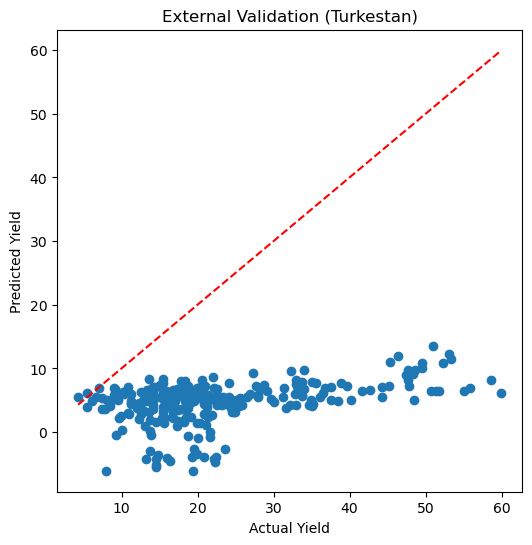

In [290]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_turk, y_pred_turk)
plt.plot(
    [y_test_turk.min(), y_test_turk.max()],
    [y_test_turk.min(), y_test_turk.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("External Validation (Turkestan)")
plt.show()

In [157]:
final_df

,District,Year,Yield,Region,NDVI_5,NDVI_6,NDVI_7,NDVI_8,NDVI_9,EVI_5,...,Temp_min,Precip_sum,NDVI_mean,EVI_mean,Soil_mean,Evap_sum,NDVI_max,EVI_max,Soil_min,GDD
0,Ayirtau,2004,8.1,North Kazakhstan,0.393176,0.573614,0.592028,0.501034,0.365928,0.205418,...,13.274447,158.086485,0.485156,0.265520,0.333414,0.022633,0.592028,0.343368,0.301684,1897.272844
1,Sandyktau,2004,8.0,Akmola,0.329663,0.482206,0.509126,0.449904,0.349671,0.167034,...,13.339836,145.653761,0.424114,0.222451,0.330555,0.003860,0.509126,0.283361,0.300797,1884.067316
2,Korghalzhyn,2004,4.6,Akmola,0.322922,0.358417,0.332739,0.324496,0.264500,0.161711,...,15.296428,136.639647,0.320615,0.159622,0.218910,0.160613,0.358417,0.182518,0.191969,2121.212444
3,Zharkaiyn,2004,7.4,Akmola,0.343167,0.386972,0.361223,0.341772,0.264400,0.184624,...,15.685595,160.273404,0.339507,0.186142,0.209852,0.004773,0.386972,0.219168,0.181298,2166.254058
4,Zhaksy,2004,9.0,Akmola,0.325260,0.409601,0.387290,0.386800,0.299381,0.168807,...,14.760399,143.404788,0.361666,0.192603,0.272071,0.001381,0.409601,0.220896,0.243851,2073.811886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Astrakhanskiy,2023,6.6,Akmola,0.321876,0.414606,0.388971,0.319879,0.352759,0.170851,...,12.574238,190.112345,0.359618,0.197153,0.282962,0.016142,0.414606,0.237322,0.246563,2087.772158
836,Arshaly,2023,5.4,Akmola,0.324923,0.382524,0.342065,0.304779,0.355918,0.178481,...,12.306782,179.479049,0.342042,0.188285,0.201152,0.018124,0.382524,0.217439,0.171593,2004.935247
837,Akkol,2023,5.1,Akmola,0.404019,0.384037,0.350694,0.359980,0.405712,0.224410,...,12.657941,173.961565,0.380888,0.209283,0.267254,0.014320,0.405712,0.224410,0.244912,2012.044968
838,Shortandy,2023,6.4,Akmola,0.302267,0.375958,0.338456,0.274948,0.304043,0.162650,...,12.456388,168.846340,0.319134,0.175647,0.318143,0.006018,0.375958,0.213795,0.289628,2044.168504


In [267]:
train_df = final_df[final_df["Region"] != "Kostanay"]
test_df = final_df[final_df["Region"] == "Kostanay"]

In [268]:
X_train = train_df[features_raw2]
y_train = train_df["Yield"]

X_test = test_df[features_raw2]
y_test = test_df["Yield"]

In [269]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.6814710522691176
MAE: 1.8191261882197463
RMSE: 2.2837087083088217


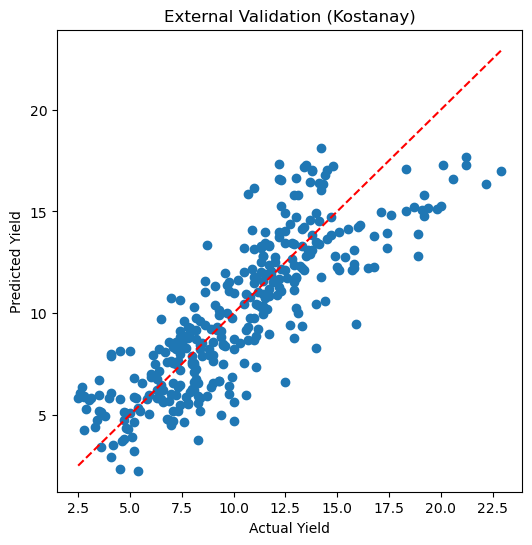

In [270]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("External Validation (Kostanay)")
plt.show()

In [271]:
baseline = X_test_raw.copy()

baseline_scaled = scaler.transform(baseline)
baseline_pred = model_linear.predict(baseline_scaled)

print("Baseline mean yield:", baseline_pred.mean())

Baseline mean yield: 9.402920114541532


In [277]:
temp_cols = ["Temp_5", "Temp_6", "Temp_8", "Temp_9"]
heat = X_test_raw.copy()
heat[temp_cols] += 3
heat_scaled = scaler.transform(heat)
heat_pred = model_linear.predict(heat_scaled)
print("Heatwave mean yield:", heat_pred.mean())

Heatwave mean yield: 9.38638585842805


In [278]:
heat = X_test_raw.copy()

heat["Temp_6"] += 2
heat["Temp_8"] += 2

heat_scaled = scaler.transform(heat)
heat_pred = model_linear.predict(heat_scaled)

print("Heatwave mean yield:", heat_pred.mean())

Heatwave mean yield: 8.093449873991487


In [280]:
ndvi_cols = ["NDVI_7", "NDVI_9"]
good = X_test_raw.copy()
good[ndvi_cols] *= 1.10
good_scaled = scaler.transform(good)
good_pred = model_linear.predict(good_scaled)

print("High NDVI mean yield:", good_pred.mean())

High NDVI mean yield: 10.020632288166718
